In [77]:
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

def read_series(path, date_col=0, usecols=None, drop_first_col=False, sort=False):
    df = pd.read_csv(path, parse_dates=[date_col], index_col=date_col, usecols=usecols)
    if drop_first_col:
        df = df.drop(columns=df.columns[0])
    s = df.squeeze()
    return s.sort_index() if sort else s


DATA = Path("/home/py/groundwater/data")
BOW_VALLEY = DATA / "bow_valley"
STREAM = BOW_VALLEY / "stream"

GOWN = pd.read_csv(DATA / "gown" / "combined_absval_20052024_filled.csv", parse_dates=[0], index_col=0)

marmot_creek_wells = ['0931', '0301', '0303', '0386', '0305']
canmore_wells = ['0764', '0760', '0759', '0364']

krns = read_series(STREAM / "krns_daily.csv")
bl   = read_series(STREAM / "05BF025_BarrierLk_TAU_Day_Mean.csv")
lkl  = read_series(STREAM / "05BF009.csv")
jcnc = read_series(STREAM / "05BH013.csv", sort=True)
brac_e = read_series(STREAM / "cr.csv", usecols=[0, 2])
brab   = read_series(STREAM / "brab_elevation.csv", usecols=[0, 2])
brac = read_series(STREAM / "cr_flow.csv", date_col=1, drop_first_col=True)

In [45]:
def monthly_stats(series, fill_mean=np.nan):
    """Return (mean, 95% CI half-width) arrays of length 12 (one per month).
    Averages within each (year, month) first, then across years.
    Months with no data get fill_mean as the mean and 0 as the CI, and False in valid"""
    df = series.to_frame('val')
    df['month'] = series.index.month
    df['year']  = series.index.year
    per_year_month = df.groupby(['year', 'month'])['val'].mean()
    agg = per_year_month.groupby('month').agg(['mean', 'std', 'count'])
    agg = agg.reindex(range(1, 13))          # ensure all 12 months present

    valid = agg['count'].fillna(0).values > 0 # true where data exists

    agg['mean'] = agg['mean'].fillna(fill_mean)
    ci = (1.96 * agg['std'] / np.sqrt(agg['count'])).fillna(0)
    return agg['mean'].values, ci.values, valid

In [5]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', 'P', '<', '>']

# Paul Tol's muted 12-colour palette — print-safe, colorblind-friendly
colors = [
    '#332288', '#117733', '#44AA99', '#88CCEE', '#DDCC77', '#CC6677',
    '#AA4499', '#882255', '#6699CC', '#999933', '#661100', '#888888'
]

In [75]:
def plot_avg_monthly_hysteresis(well, river_series, title, start='2006', end='2023', ylab='Flow (m³/s)'):
    fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

    flow_mean, flow_ci, flow_valid = monthly_stats(river_series.loc[start:end])
    gw_mean,   gw_ci, gw_valid   = monthly_stats(well.loc[start:end])

    # for seasonal stations
    valid = flow_valid & gw_valid
    valid_months = np.where(valid)[0]
    if len(valid_months) == 0:
        raise ValueError("No months with overlapping data in this date range.")

    # Grey connecting line looped back to Jan
    flow_loop = np.append(flow_mean[valid_months], flow_mean[valid_months[0]])
    gw_loop   = np.append(gw_mean[valid_months],   gw_mean[valid_months[0]])
    ax.plot(flow_loop, gw_loop, linestyle='-', color='#aaaaaa', alpha=0.4, linewidth=1)

    # 95 % CI error bars drawn first so markers sit on top
    for m in valid_months:
        ax.errorbar(flow_mean[m], gw_mean[m],
                    xerr=flow_ci[m], yerr=gw_ci[m],
                    fmt='none', ecolor=colors[m], elinewidth=1.2,
                    capsize=3, capthick=1.0, alpha=0.75, zorder=3)

    # Month scatter points
    for m in valid_months:
        ax.scatter(flow_mean[m], gw_mean[m],
                   marker=markers[m], color=colors[m], s=90, zorder=5,
                   edgecolors='white', linewidth=0.5, label=month_names[m])

    # Directional arrows Jan → … → Dec → Jan
    for i, m in enumerate(valid_months):
        nxt = valid_months[(i+1)%len(valid_months)]
        ax.annotate('',
                    xy=(flow_mean[nxt], gw_mean[nxt]),
                    xytext=(flow_mean[m], gw_mean[m]),
                    arrowprops=dict(arrowstyle='-|>', color='#444444', lw=0.9,
                                    alpha=0.6, shrinkA=7, shrinkB=7))

    from matplotlib.ticker import ScalarFormatter
    for axis in (ax.xaxis, ax.yaxis):
        fmt = ScalarFormatter(useOffset=False)
        fmt.set_scientific(False)
        axis.set_major_formatter(fmt)

    ax.set_xlabel(ylab, fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel('Groundwater Level (mamsl)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    ax.legend(fontsize=8.5, loc='best', ncol=3, title='Month (Jan→Dec)',
              title_fontsize=8.5, handletextpad=0.4, borderpad=0.6, framealpha=0.85)

# Bow River at Banff vs Canmore Wells

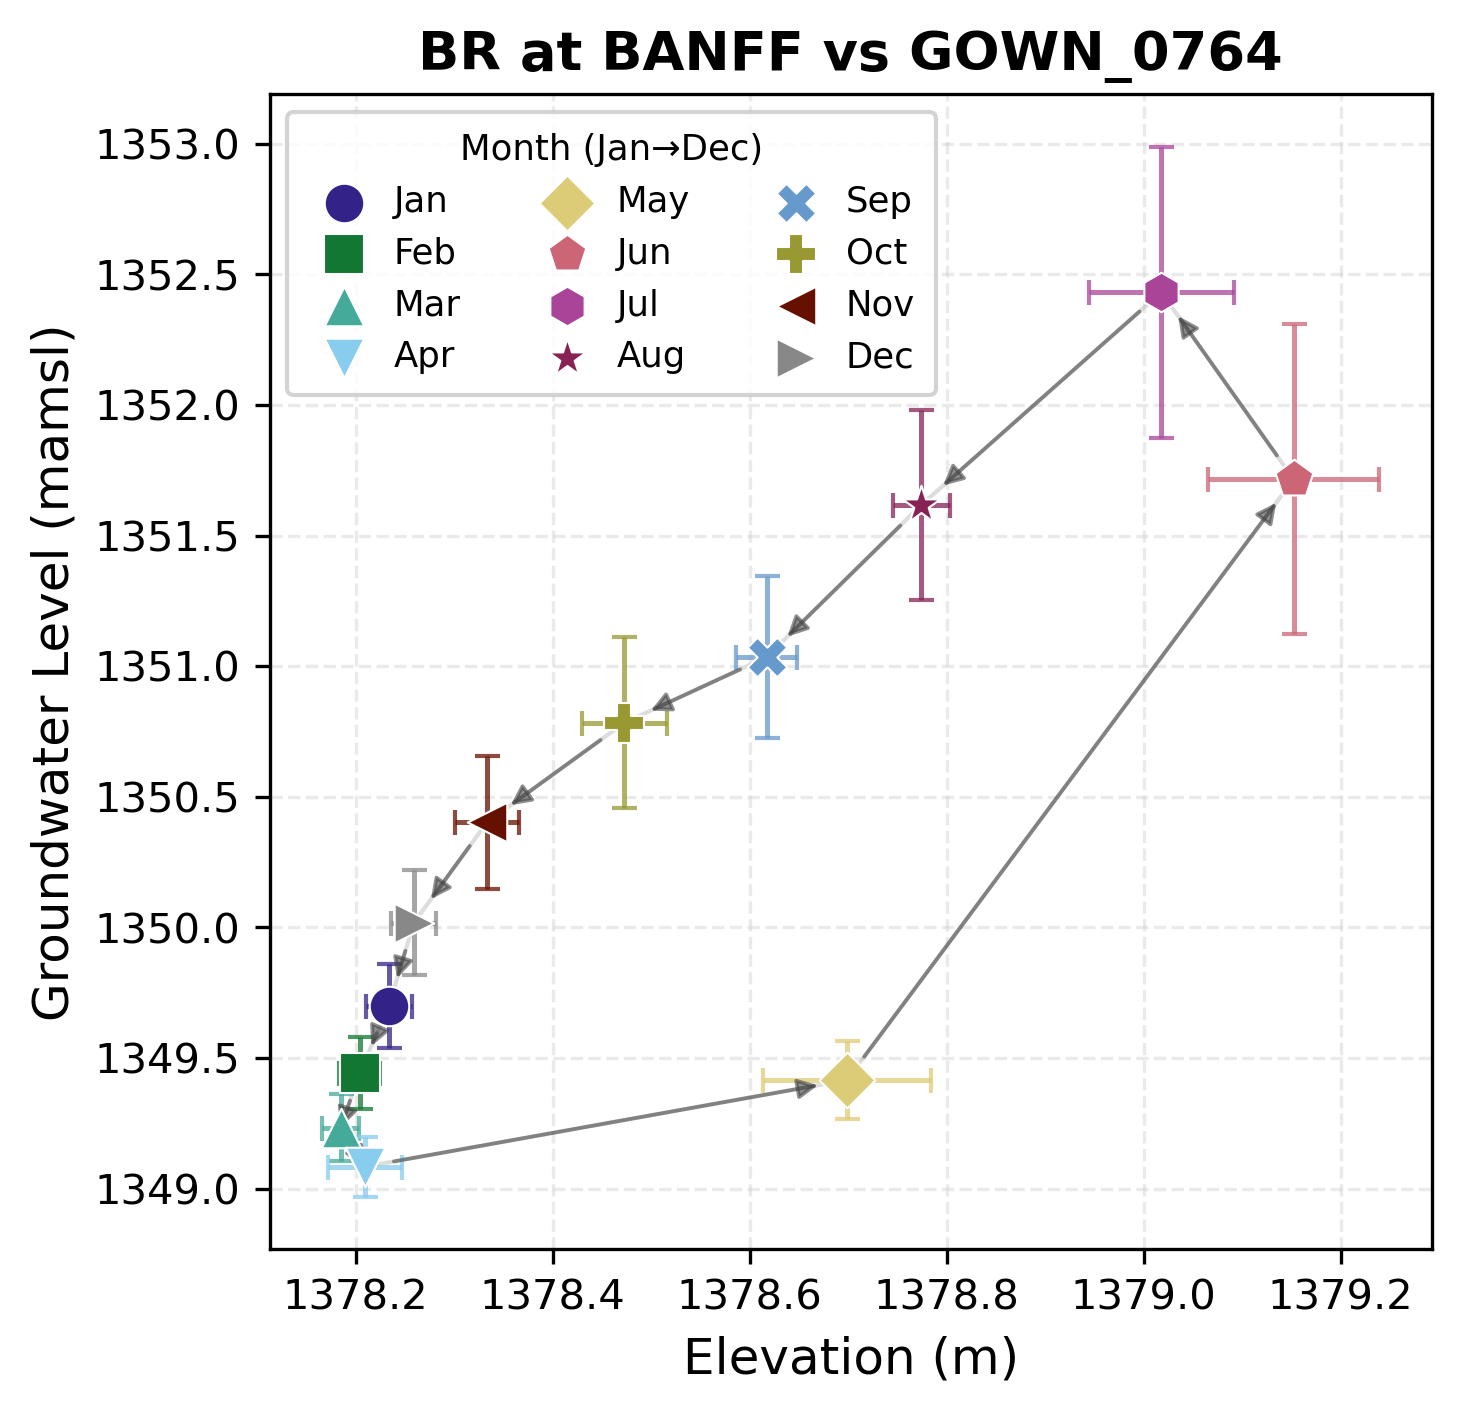

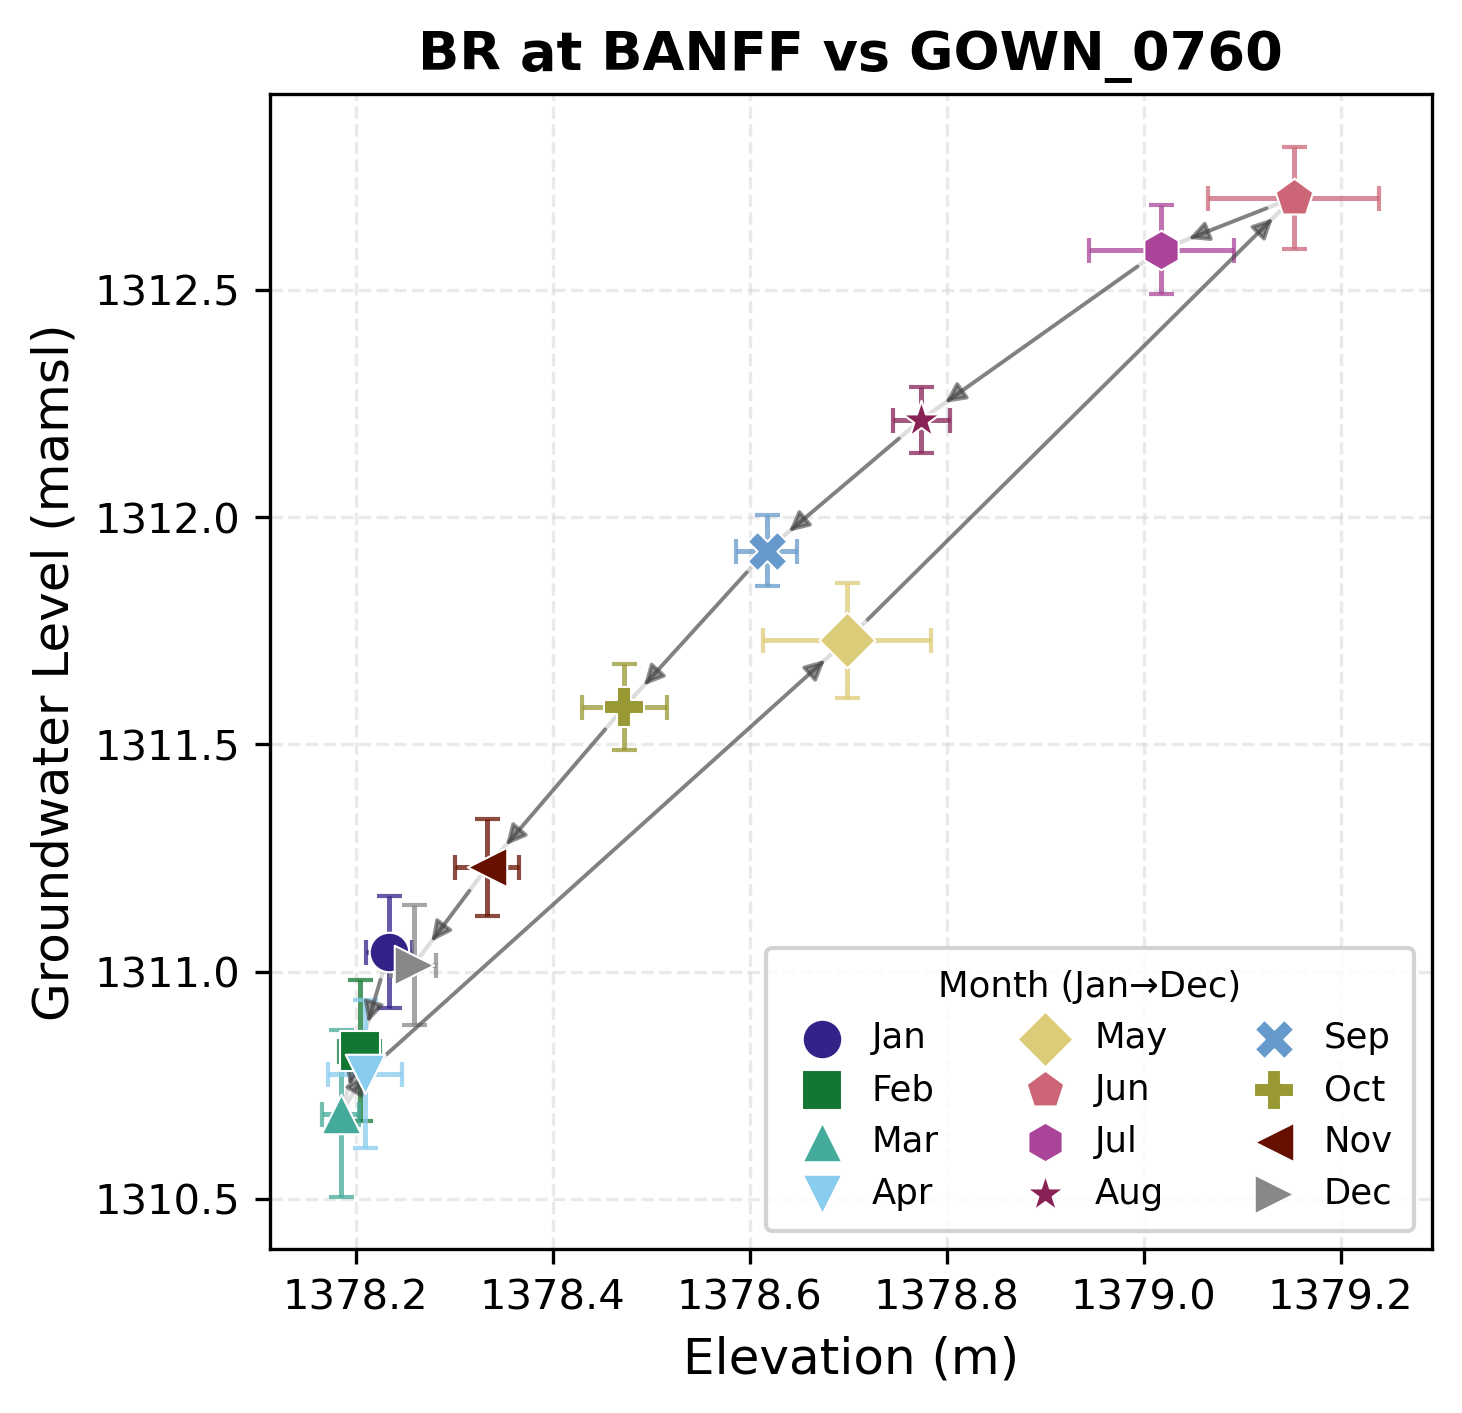

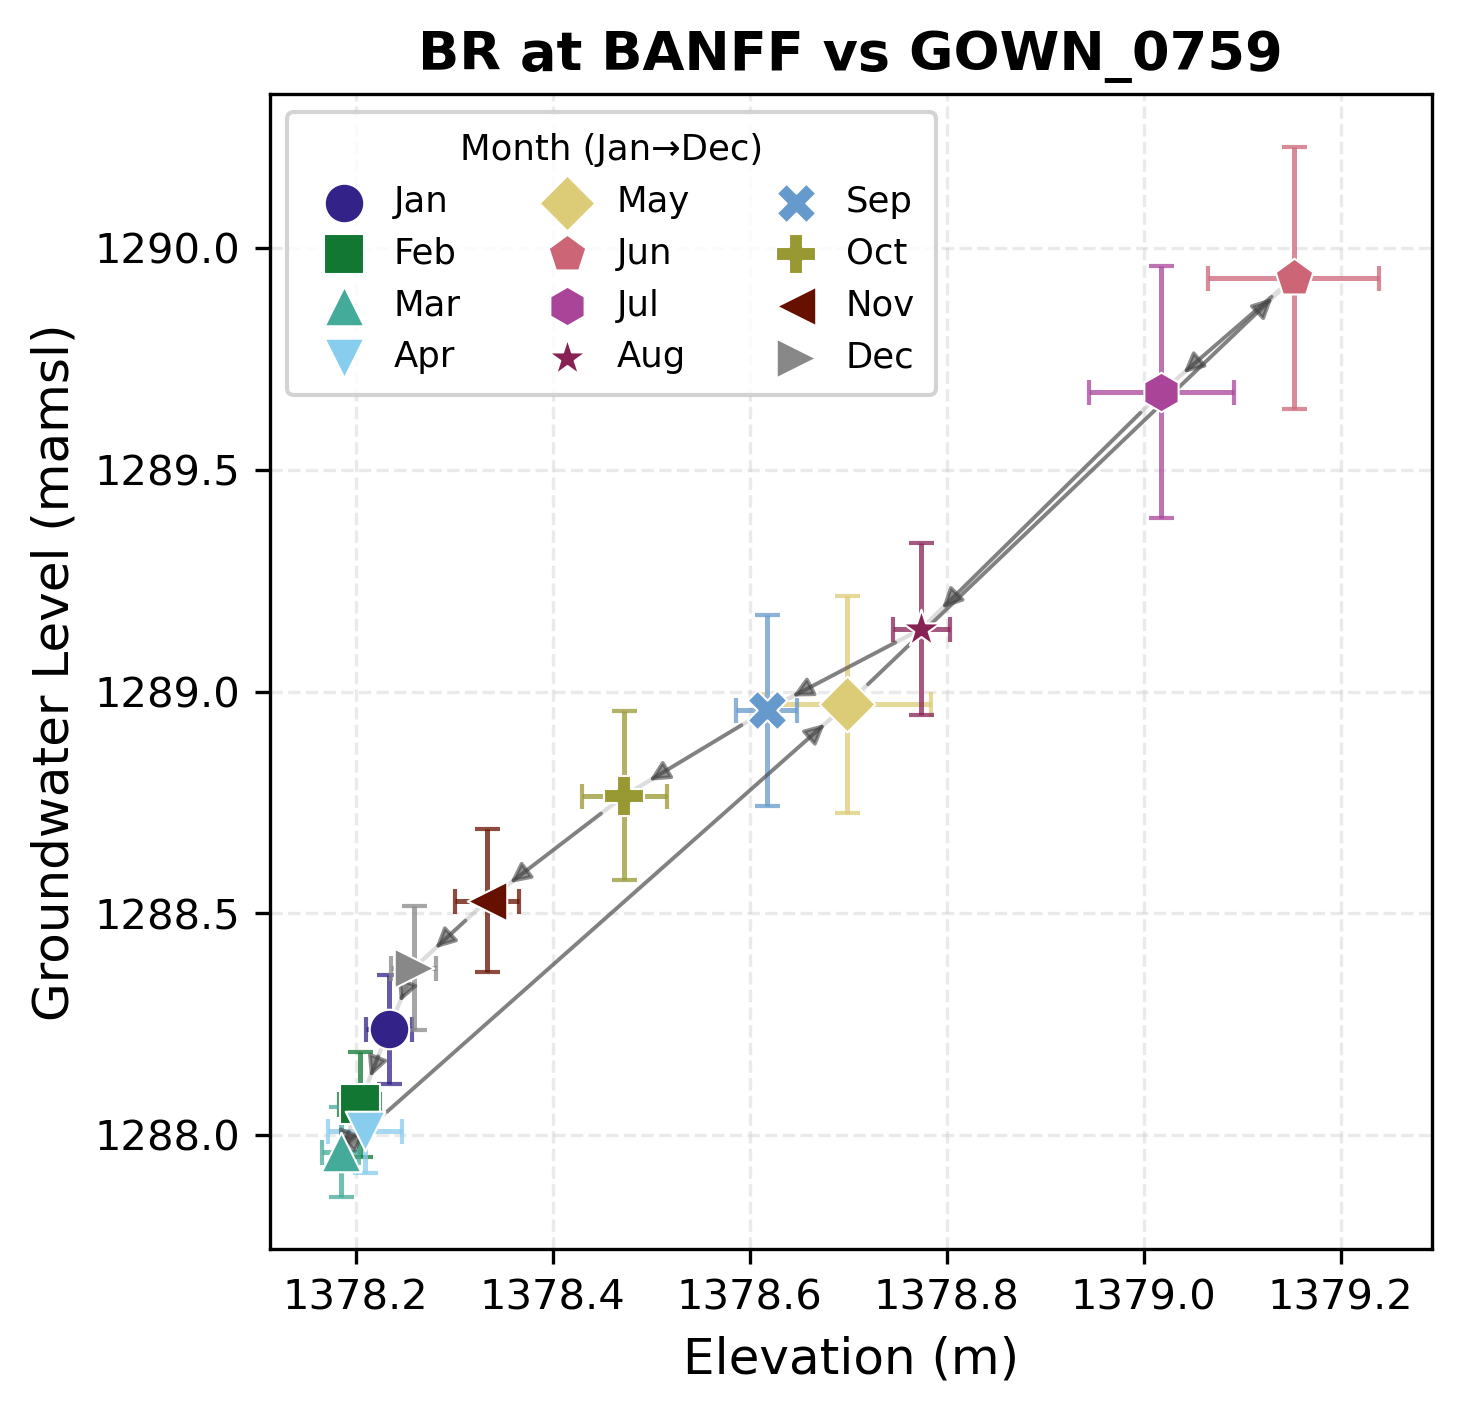

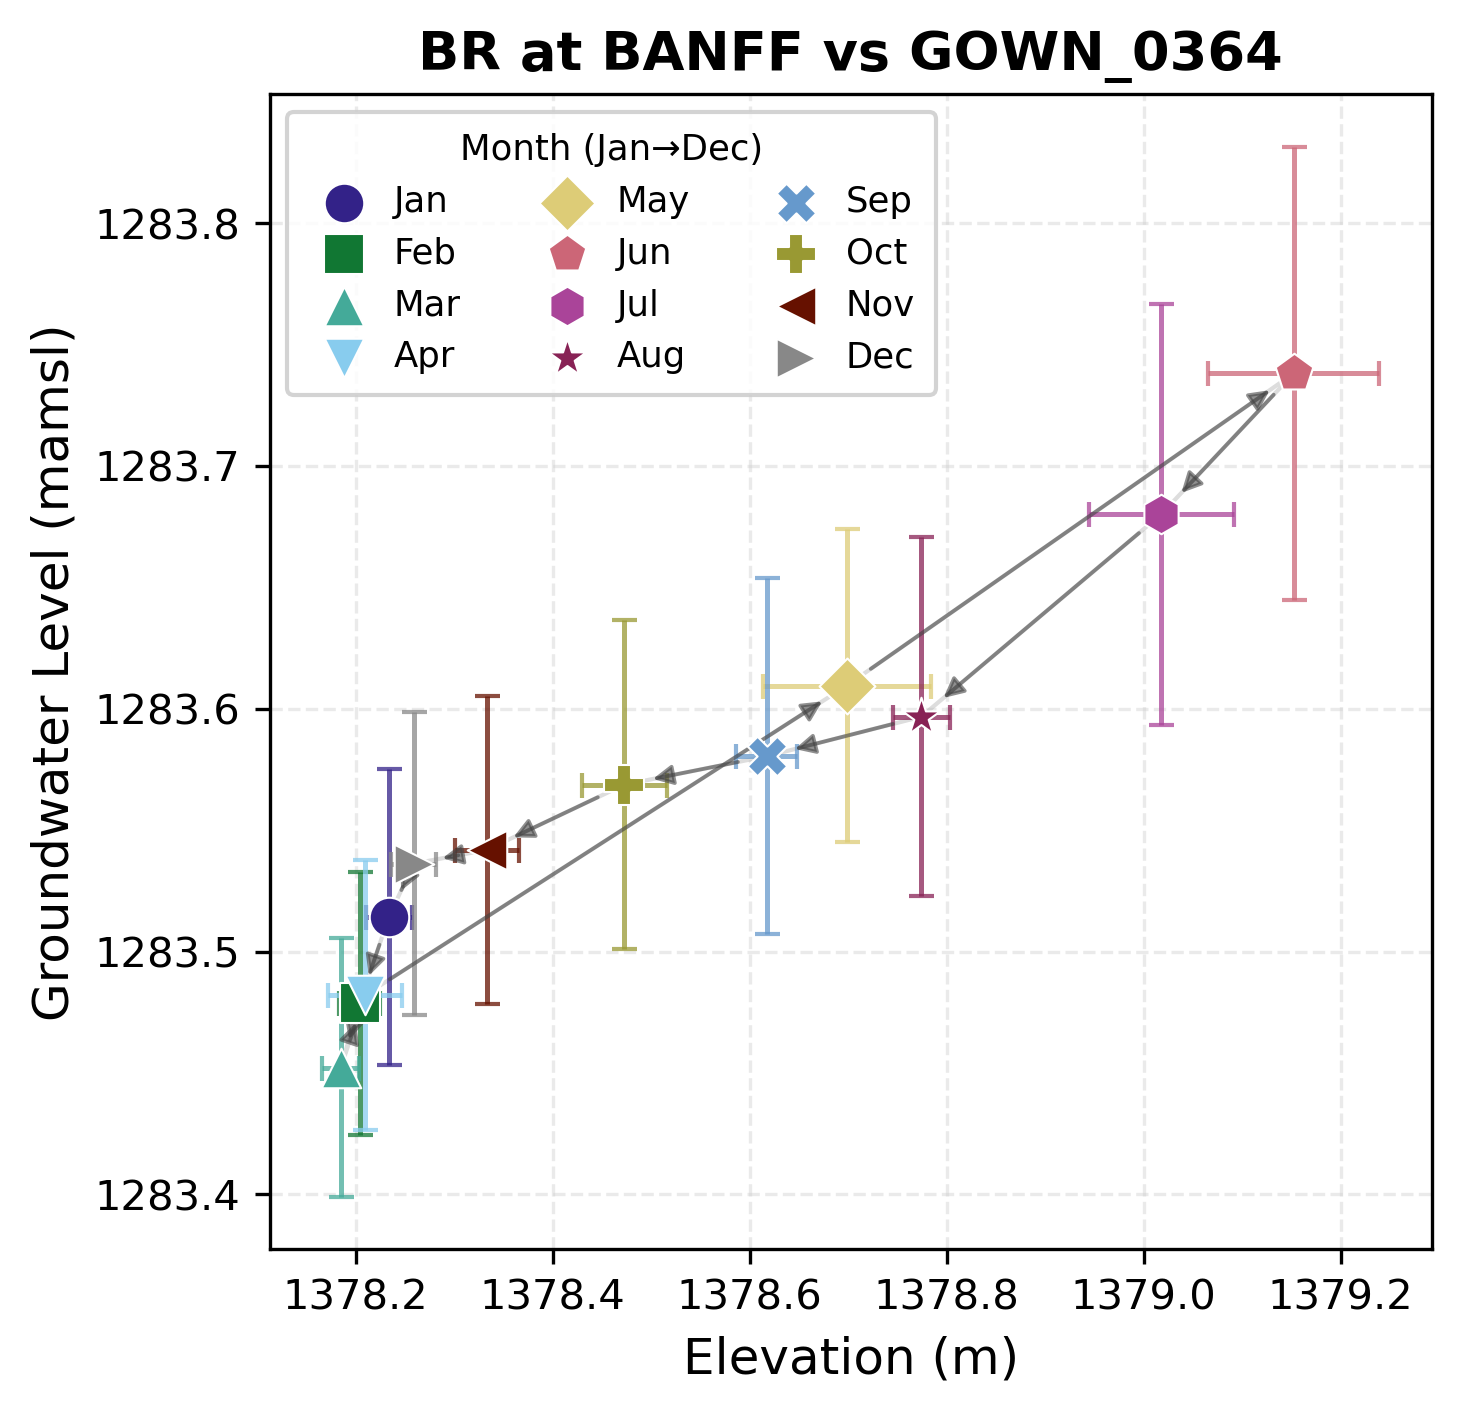

In [68]:
for well in canmore_wells:
    plot_avg_monthly_hysteresis(GOWN[well], brab, f'BR at BANFF vs GOWN_{well}', start='2005', end='2024', ylab='Elevation (m)')

# Bow River at Canmore (Predicted Flow and Elevation) vs Canmore Wells

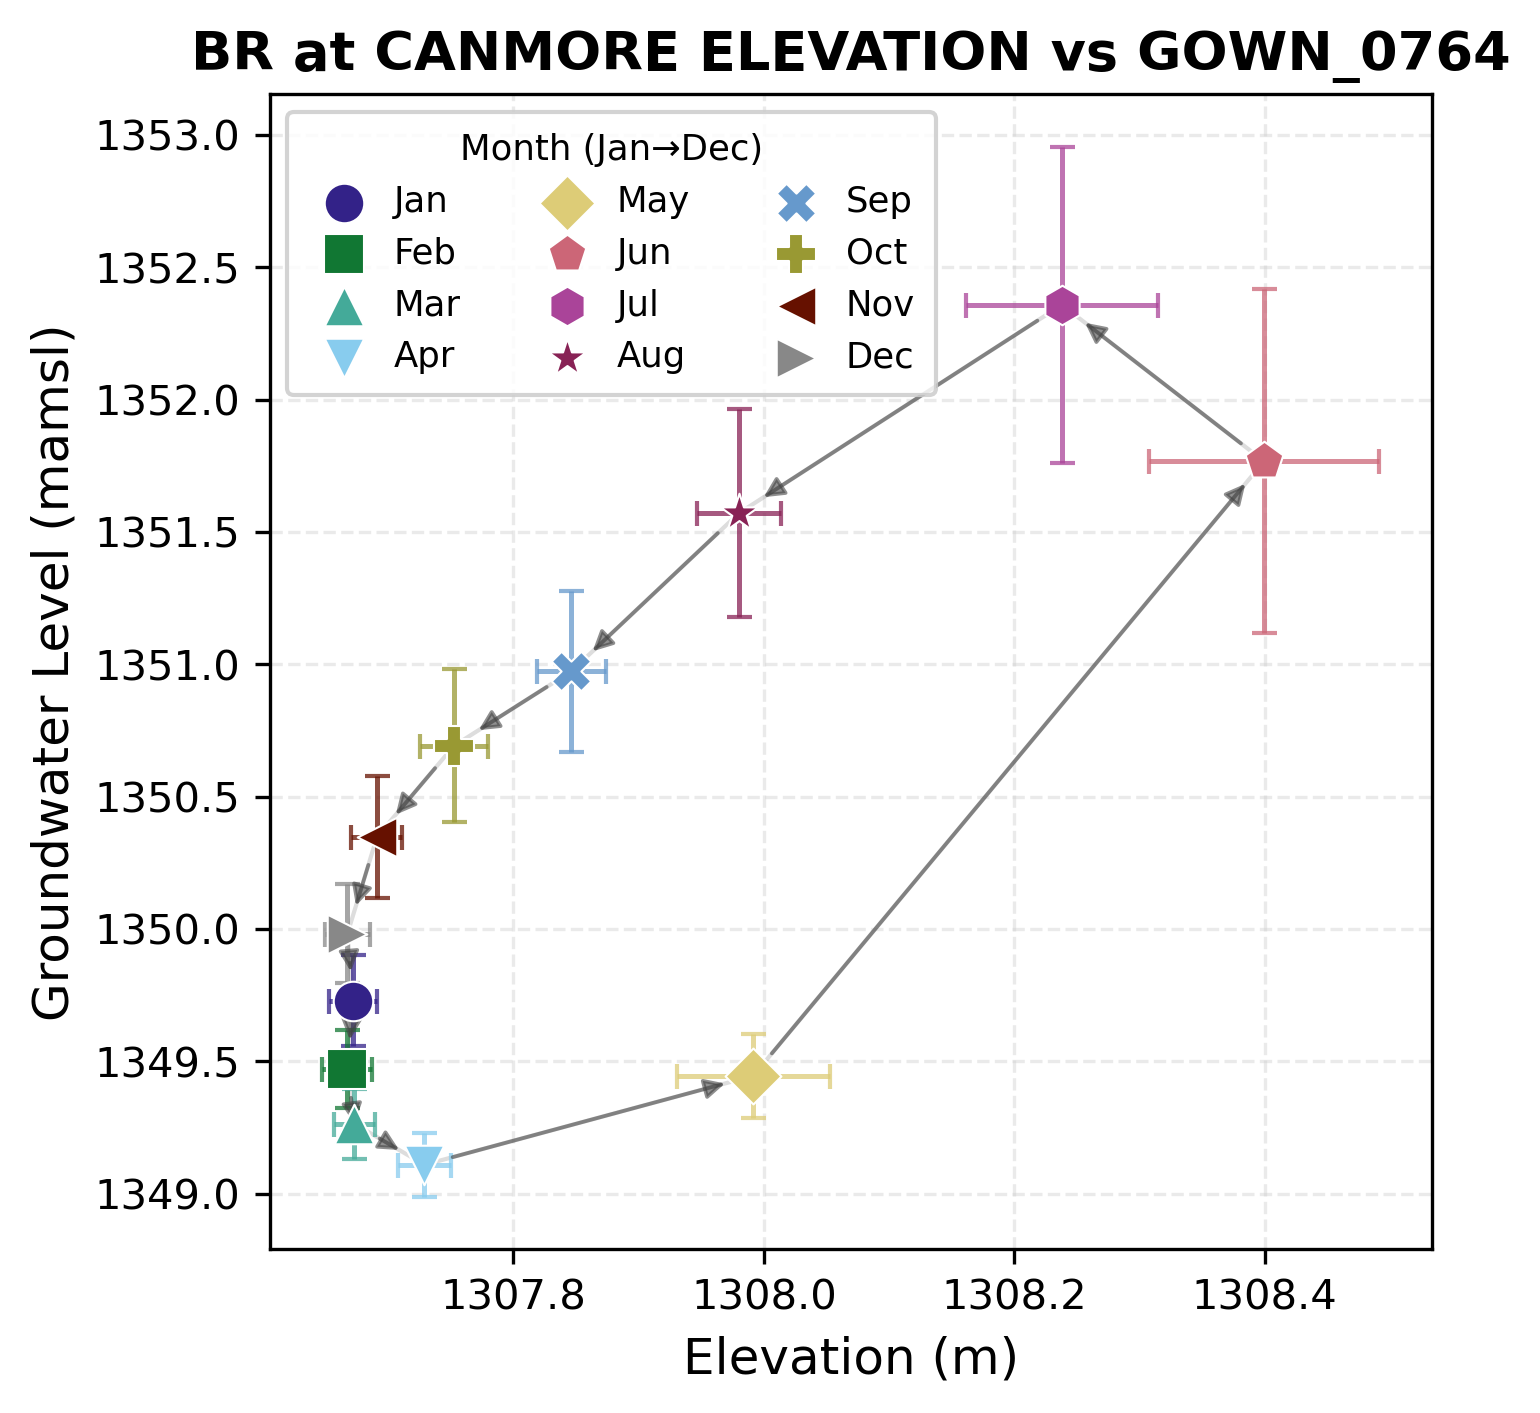

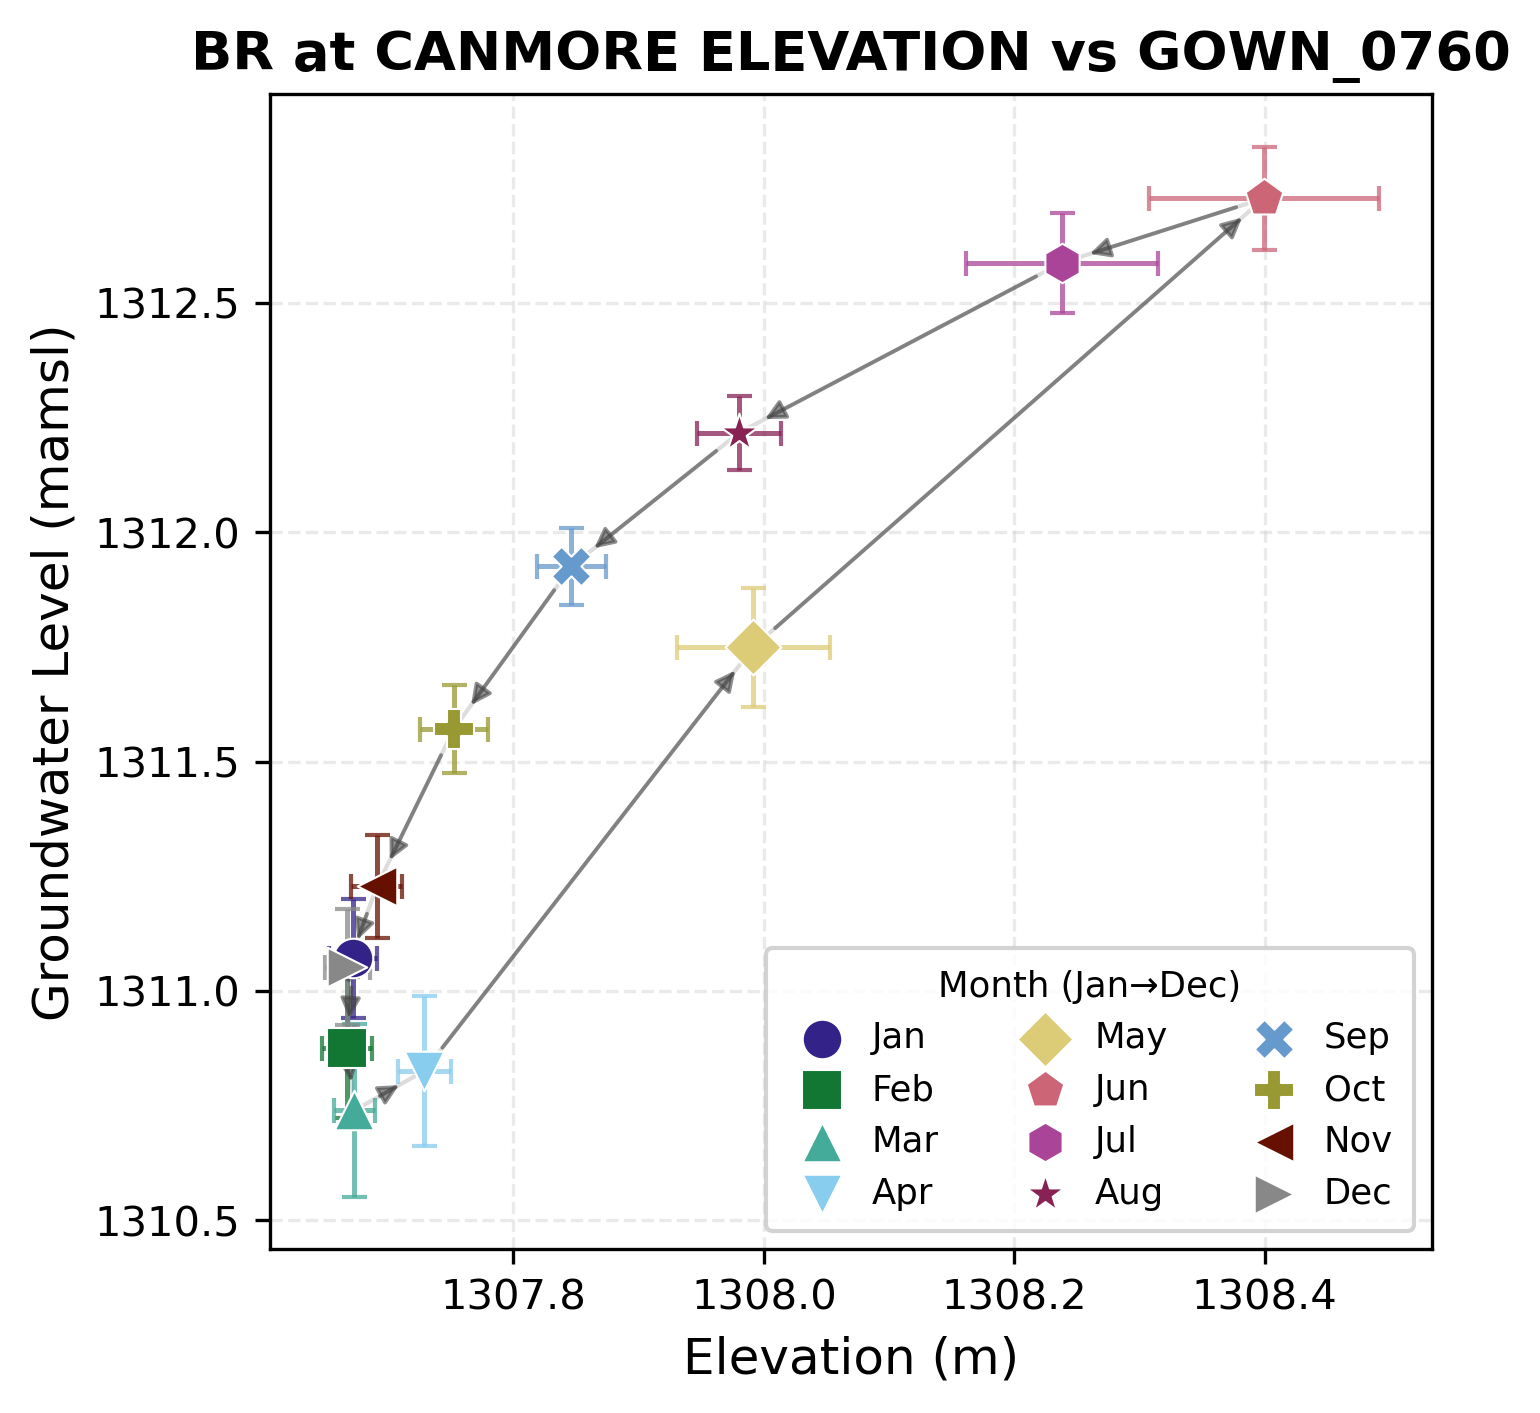

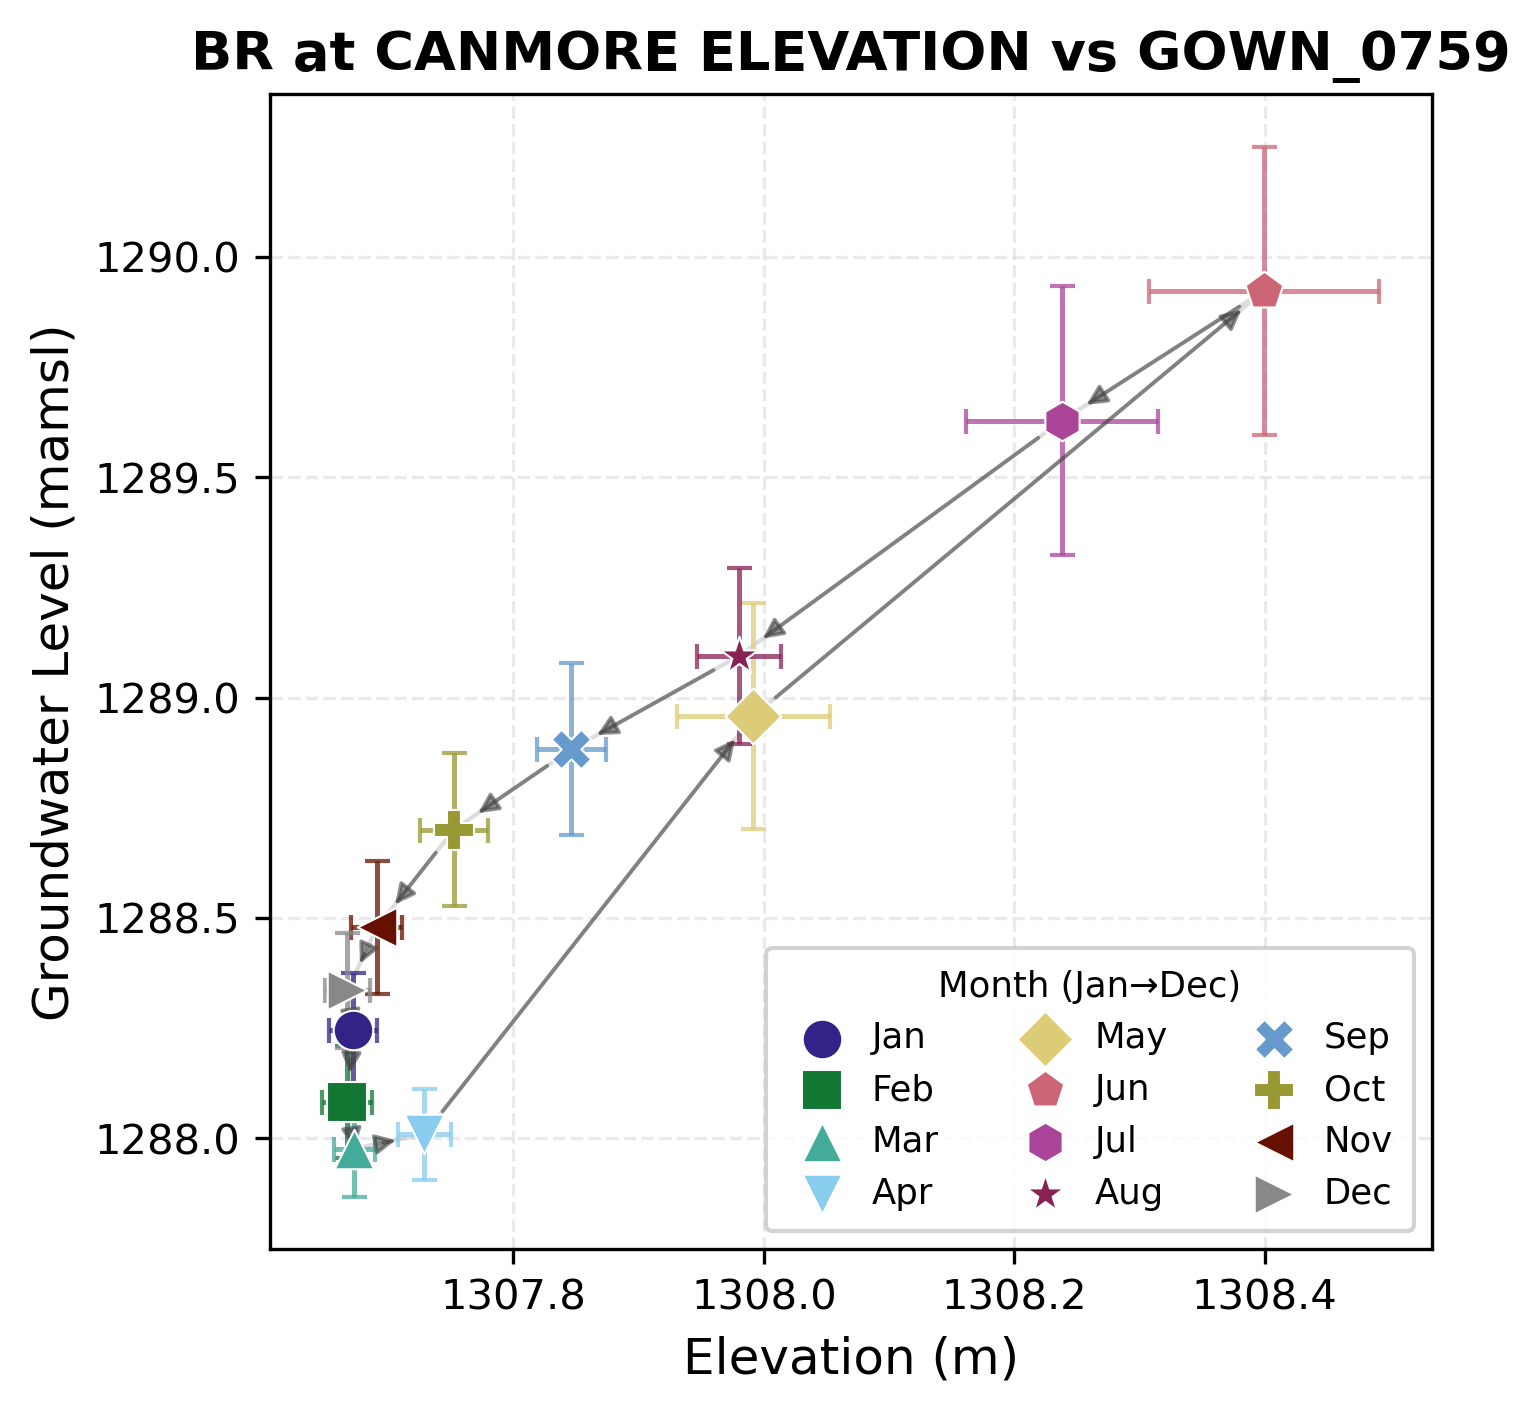

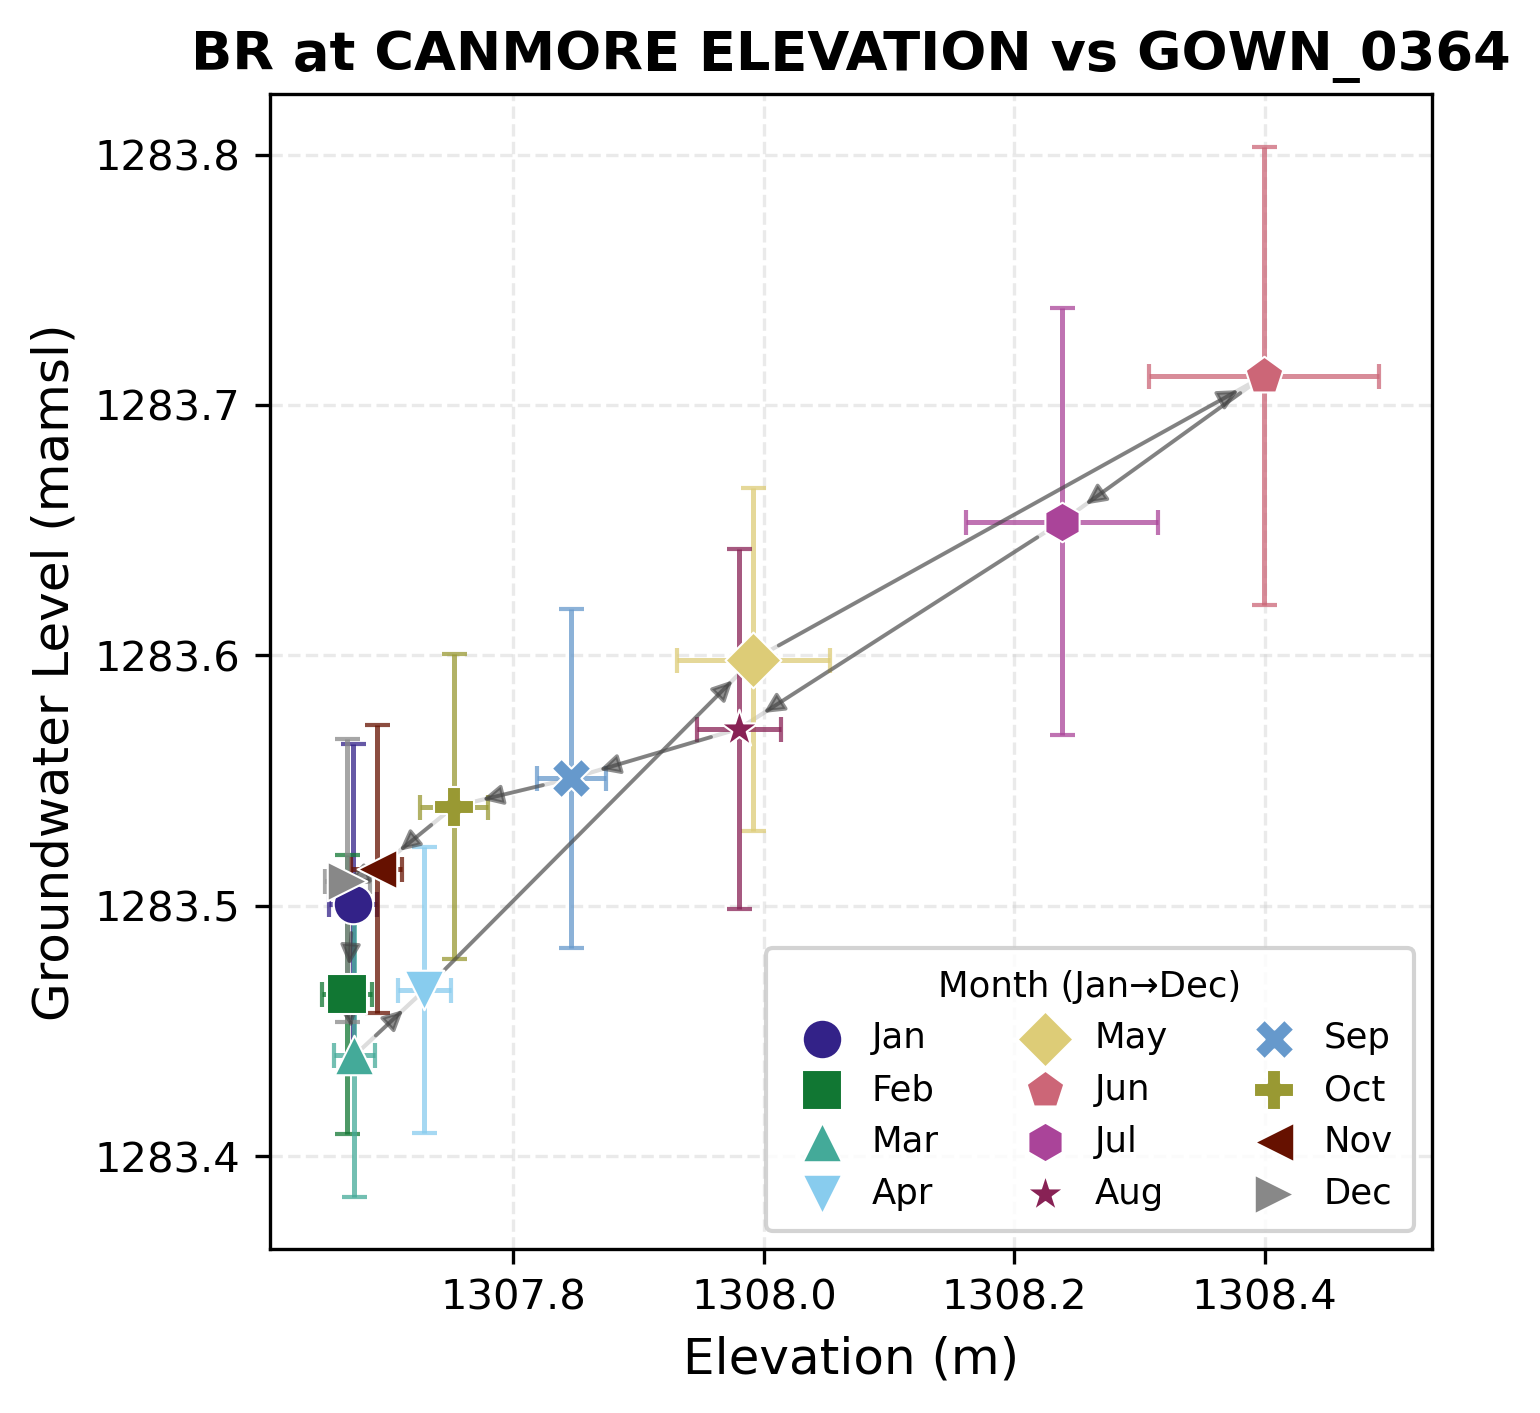

In [11]:
for well in canmore_wells:
    plot_avg_monthly_hysteresis(GOWN[well], brac_e, f'BR at CANMORE ELEVATION vs GOWN_{well}', ylab='Elevation (m)')

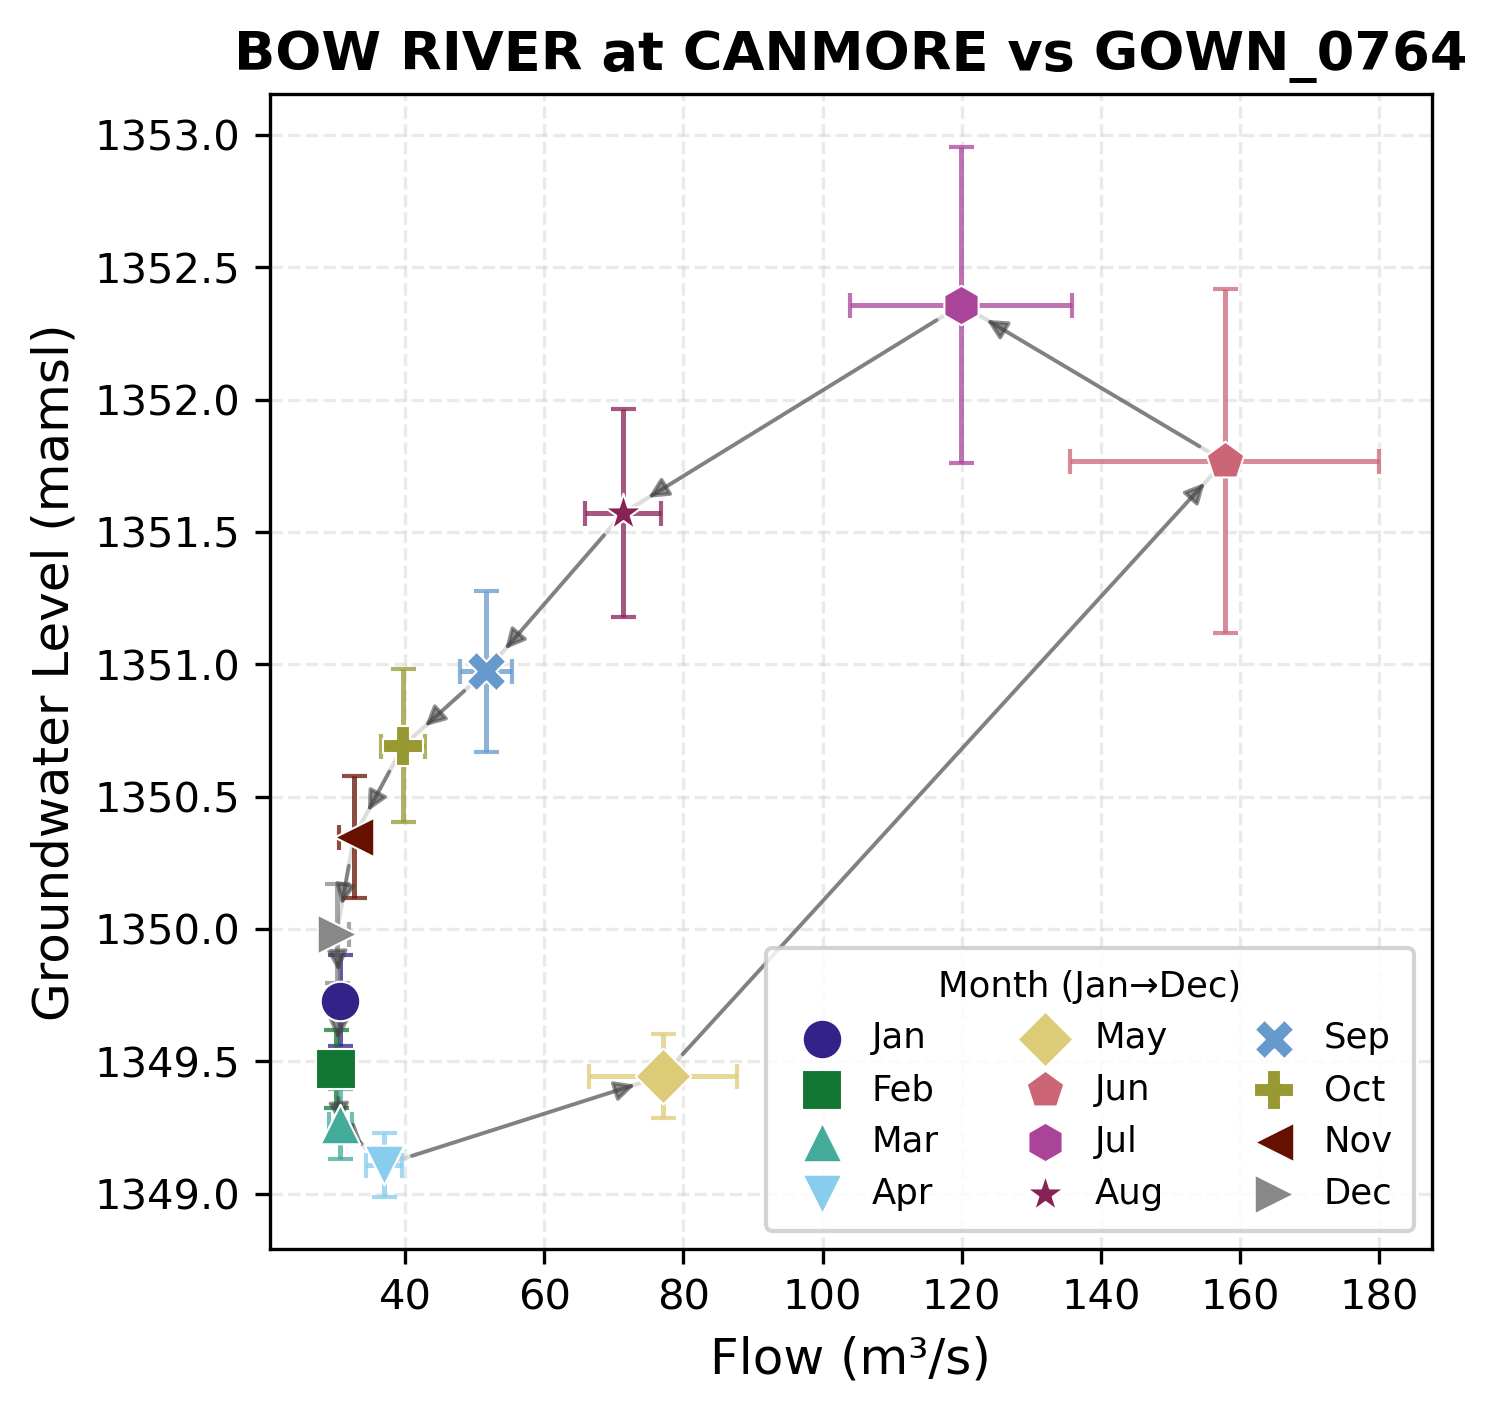

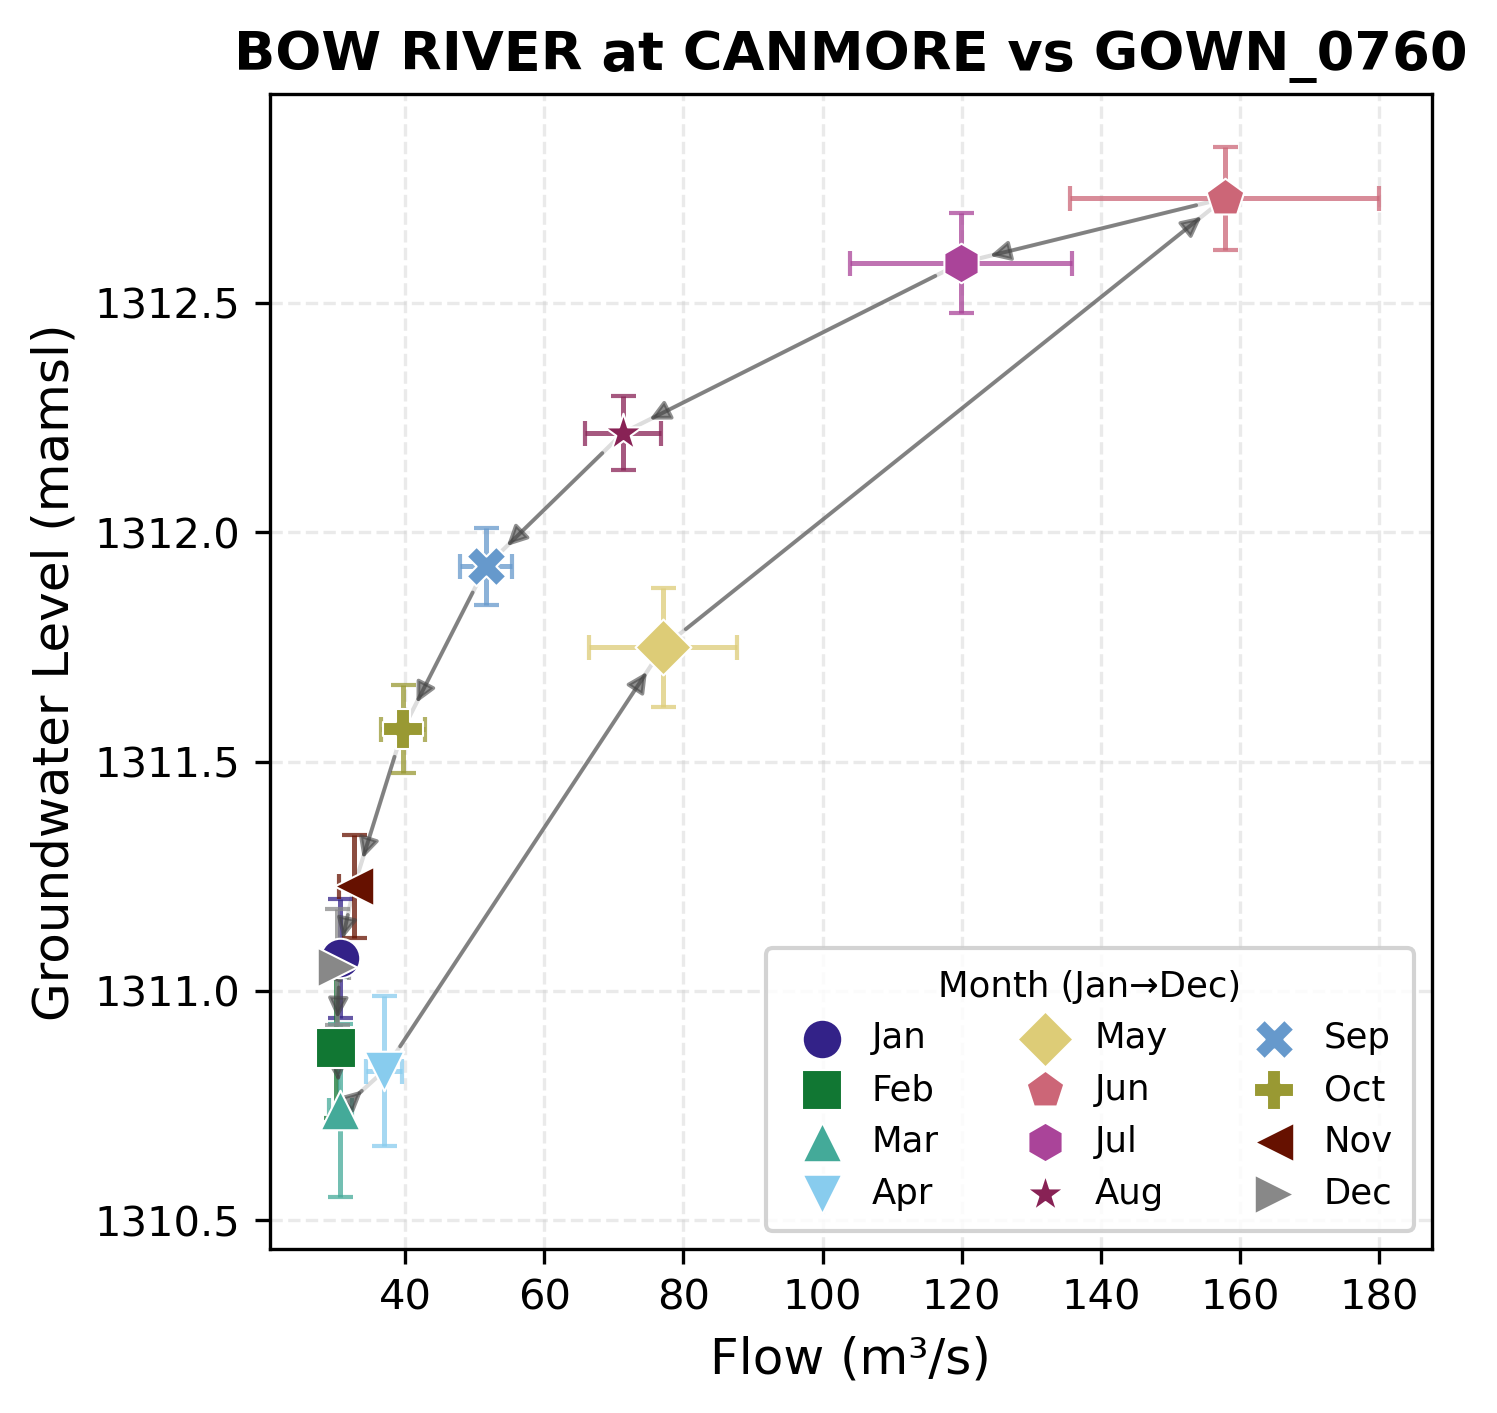

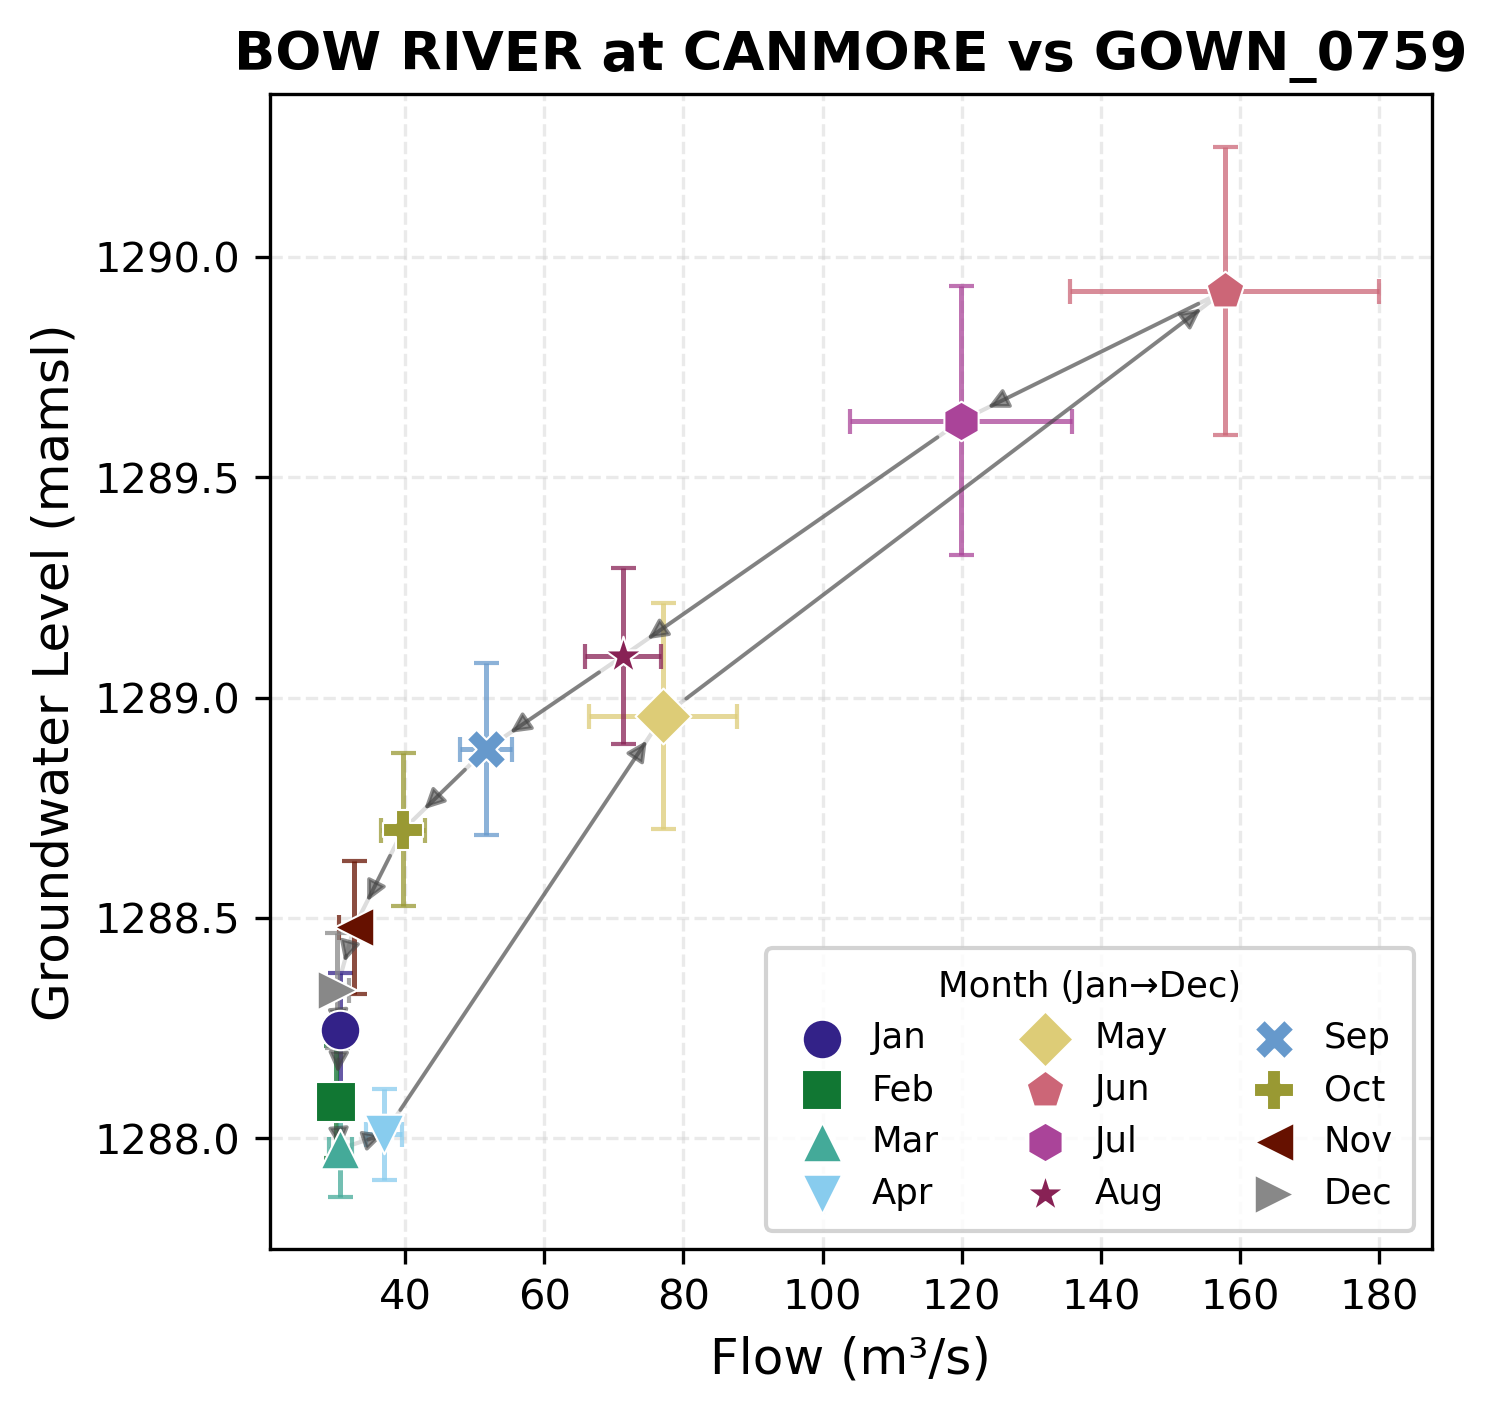

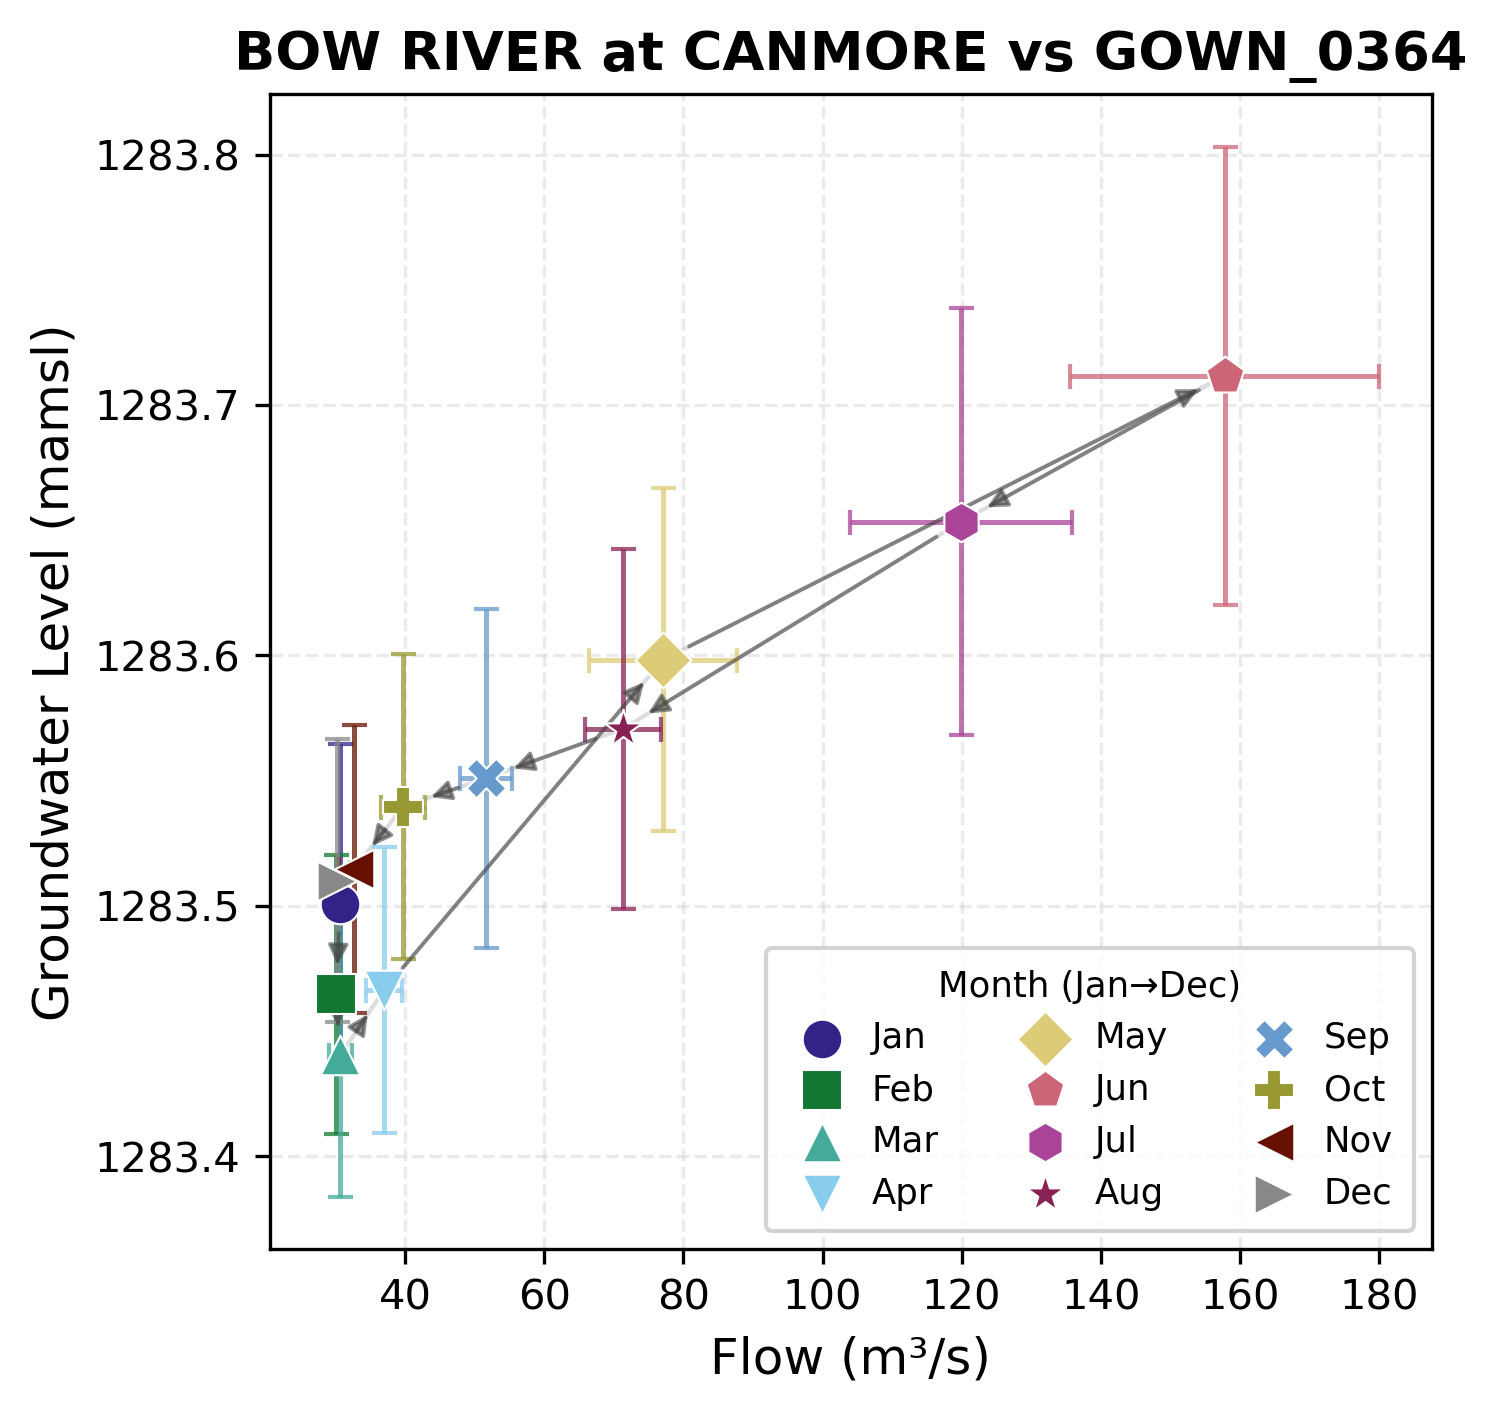

In [43]:
for well in canmore_wells:
    plot_avg_monthly_hysteresis(GOWN[well], brac, f'BOW RIVER at CANMORE vs GOWN_{well}')

# Kananaskis River near Seebe vs MC Wells

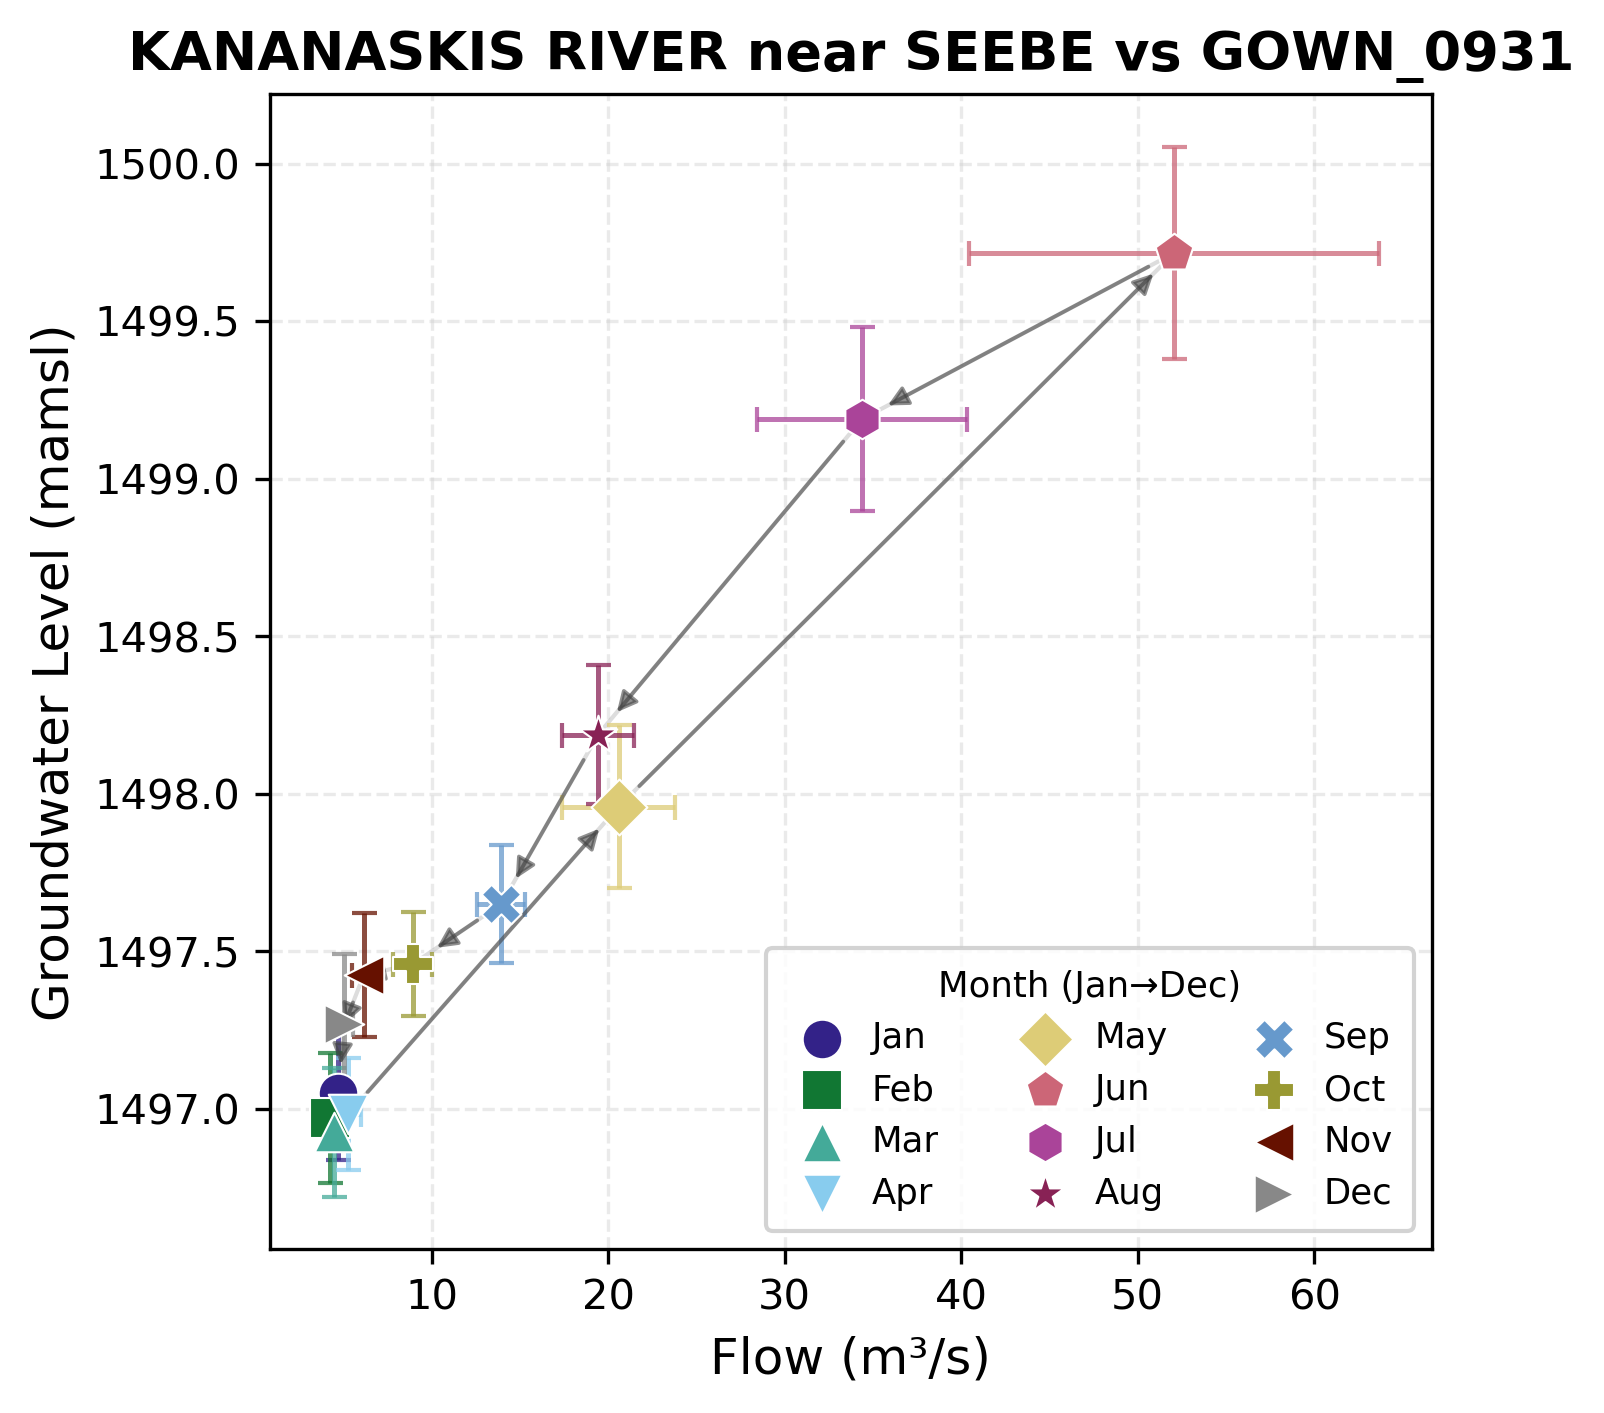

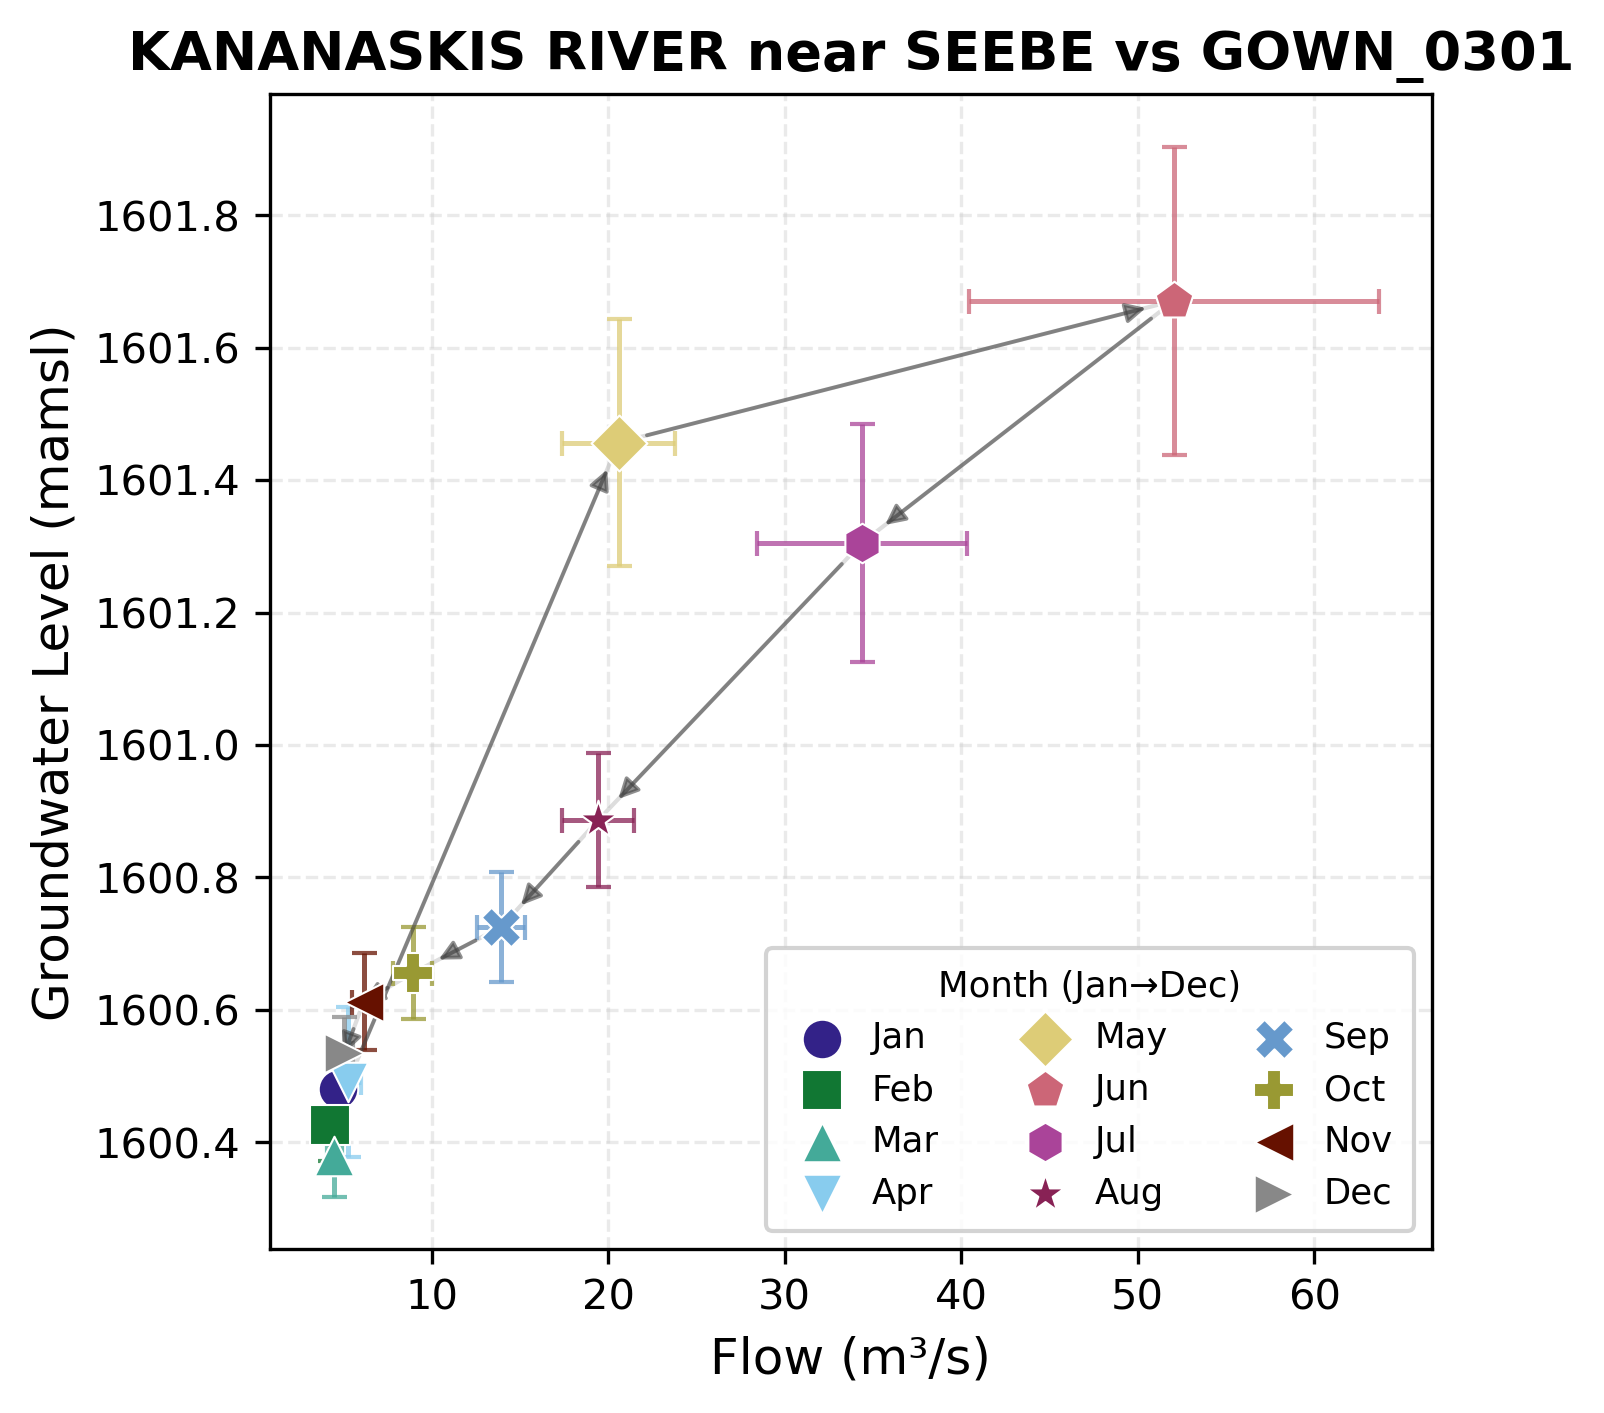

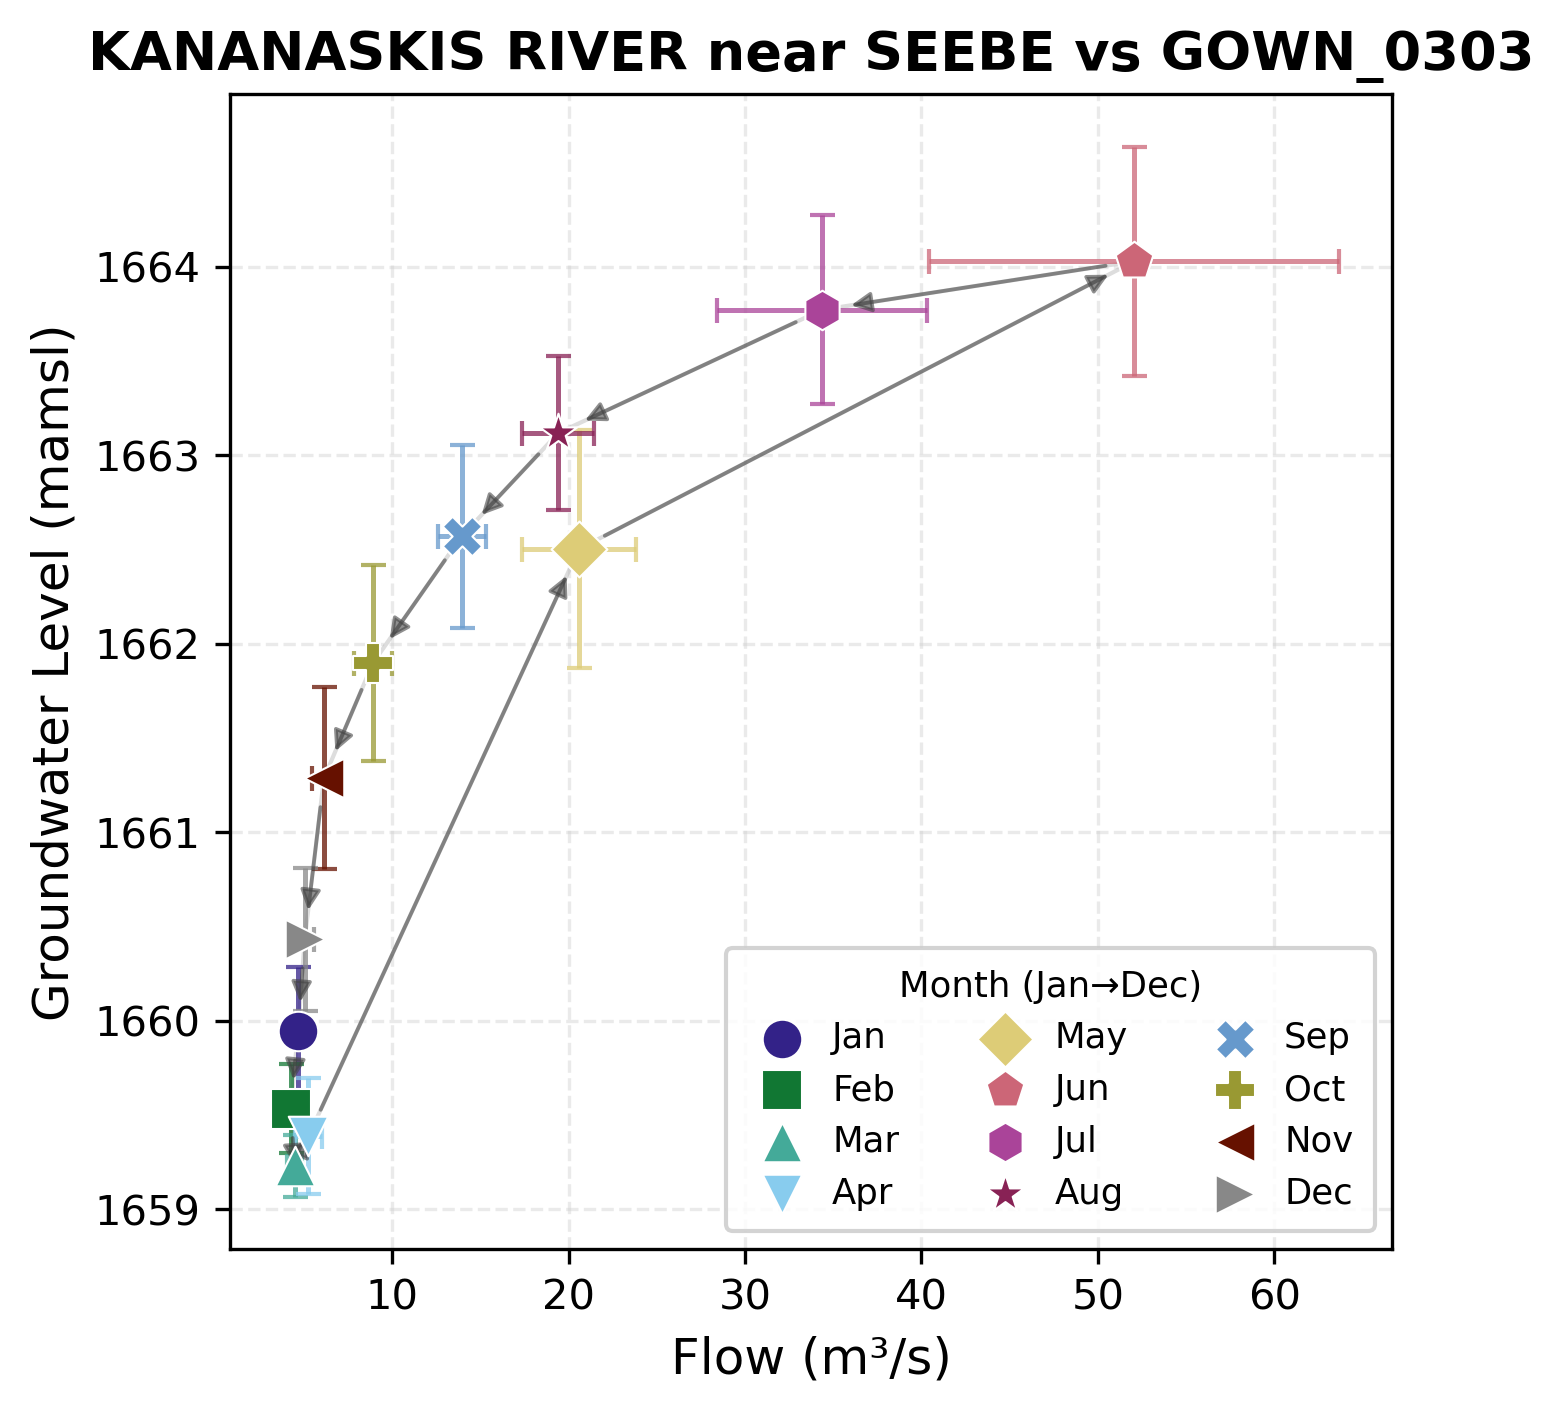

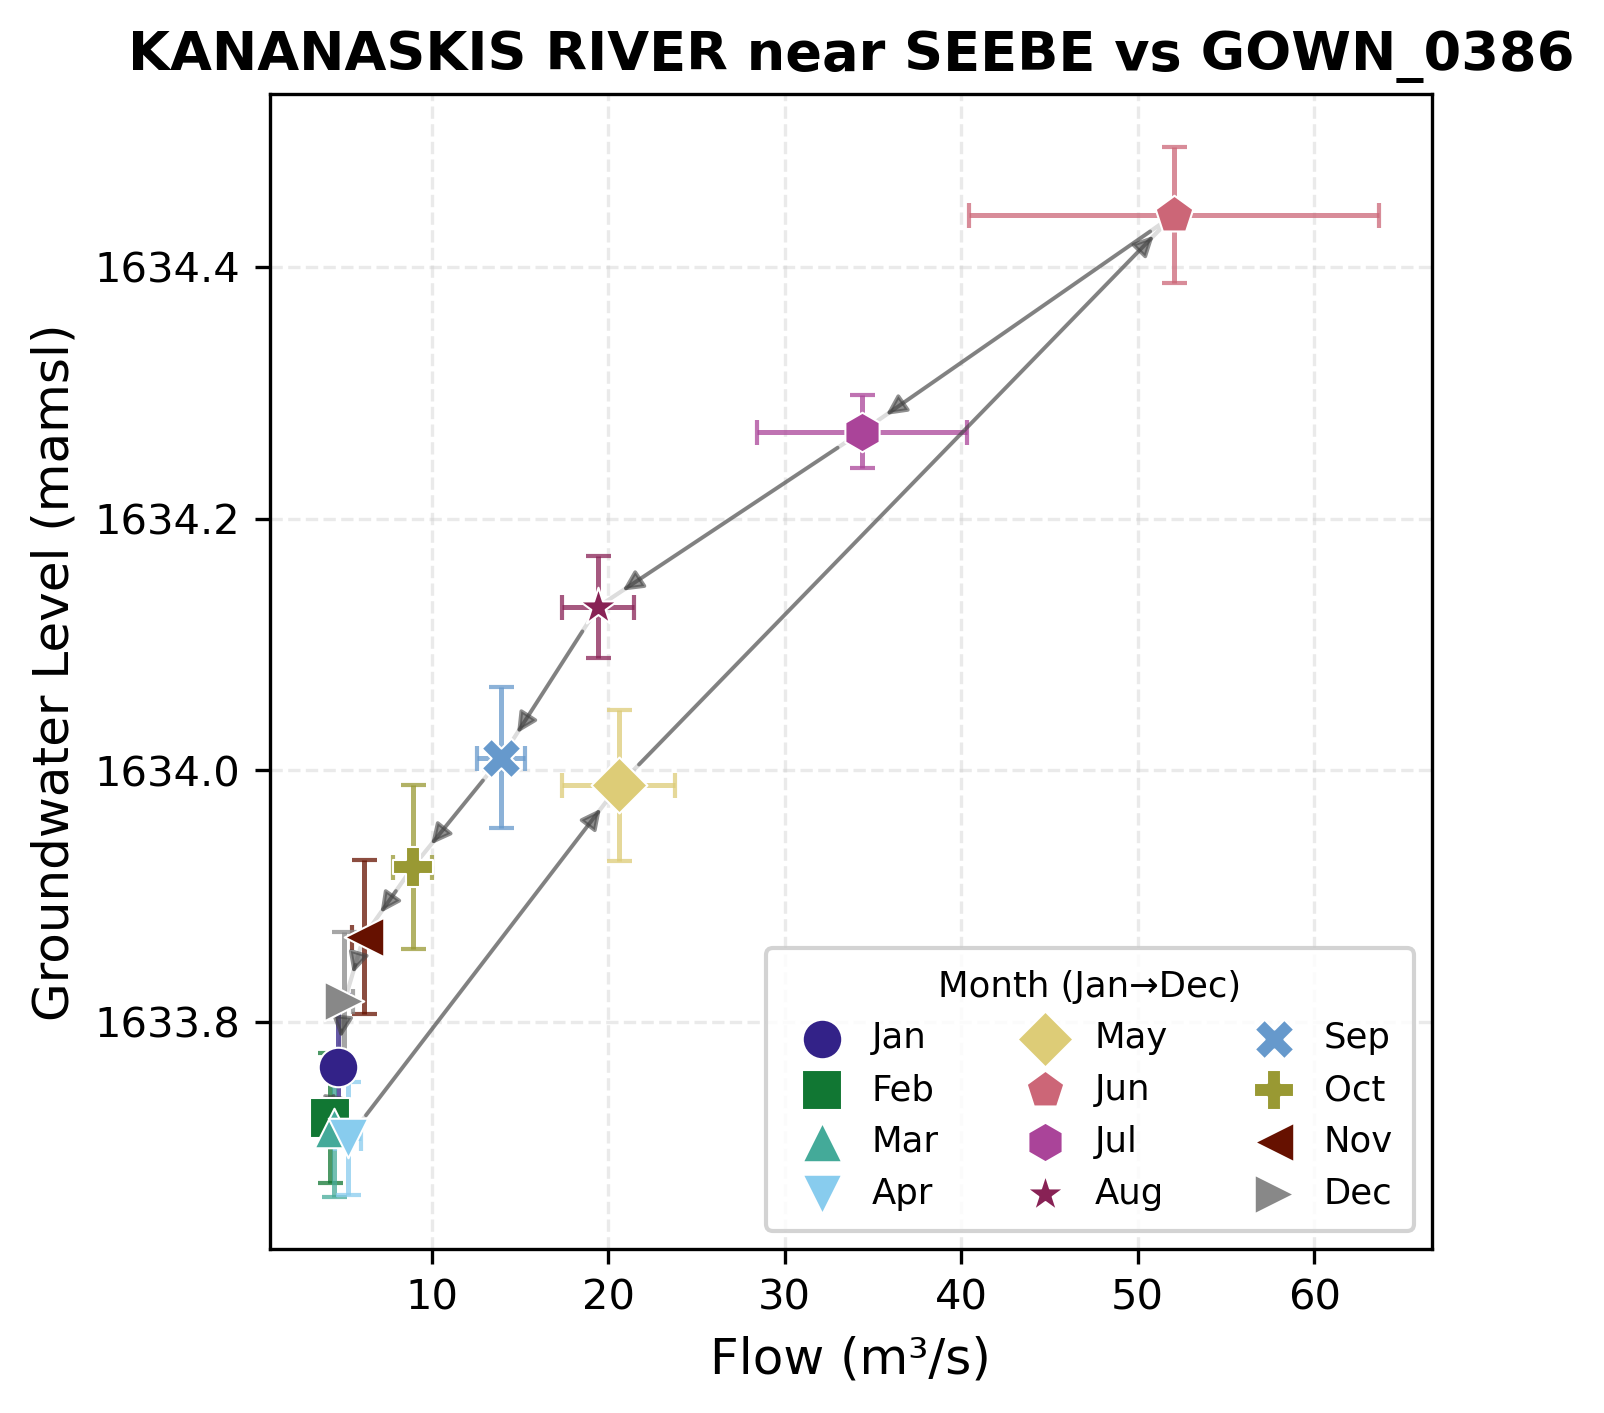

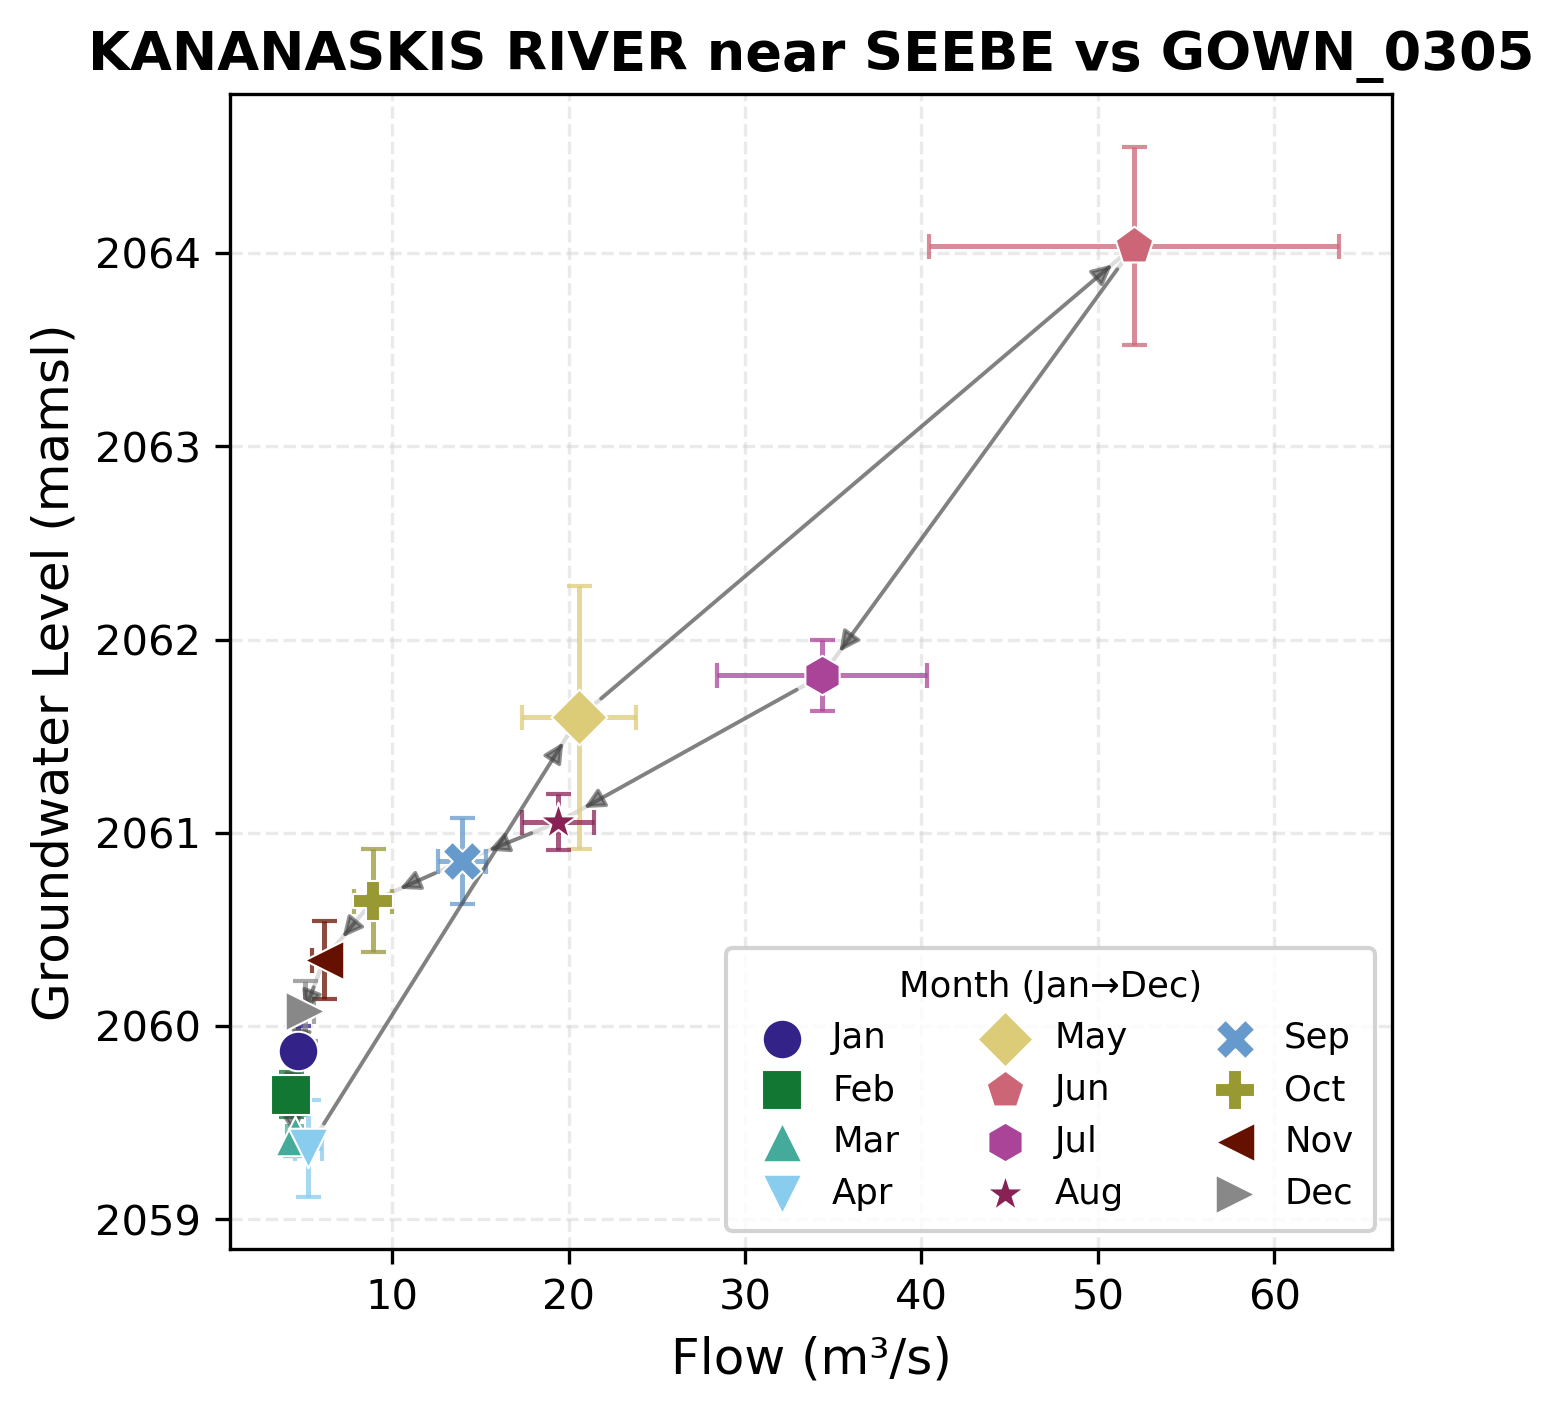

In [44]:
for well in marmot_creek_wells:
    plot_avg_monthly_hysteresis(GOWN[well], krns, f'KANANASKIS RIVER near SEEBE vs GOWN_{well}')

# Kananaskis River below Barrier Dam vs MC Wells

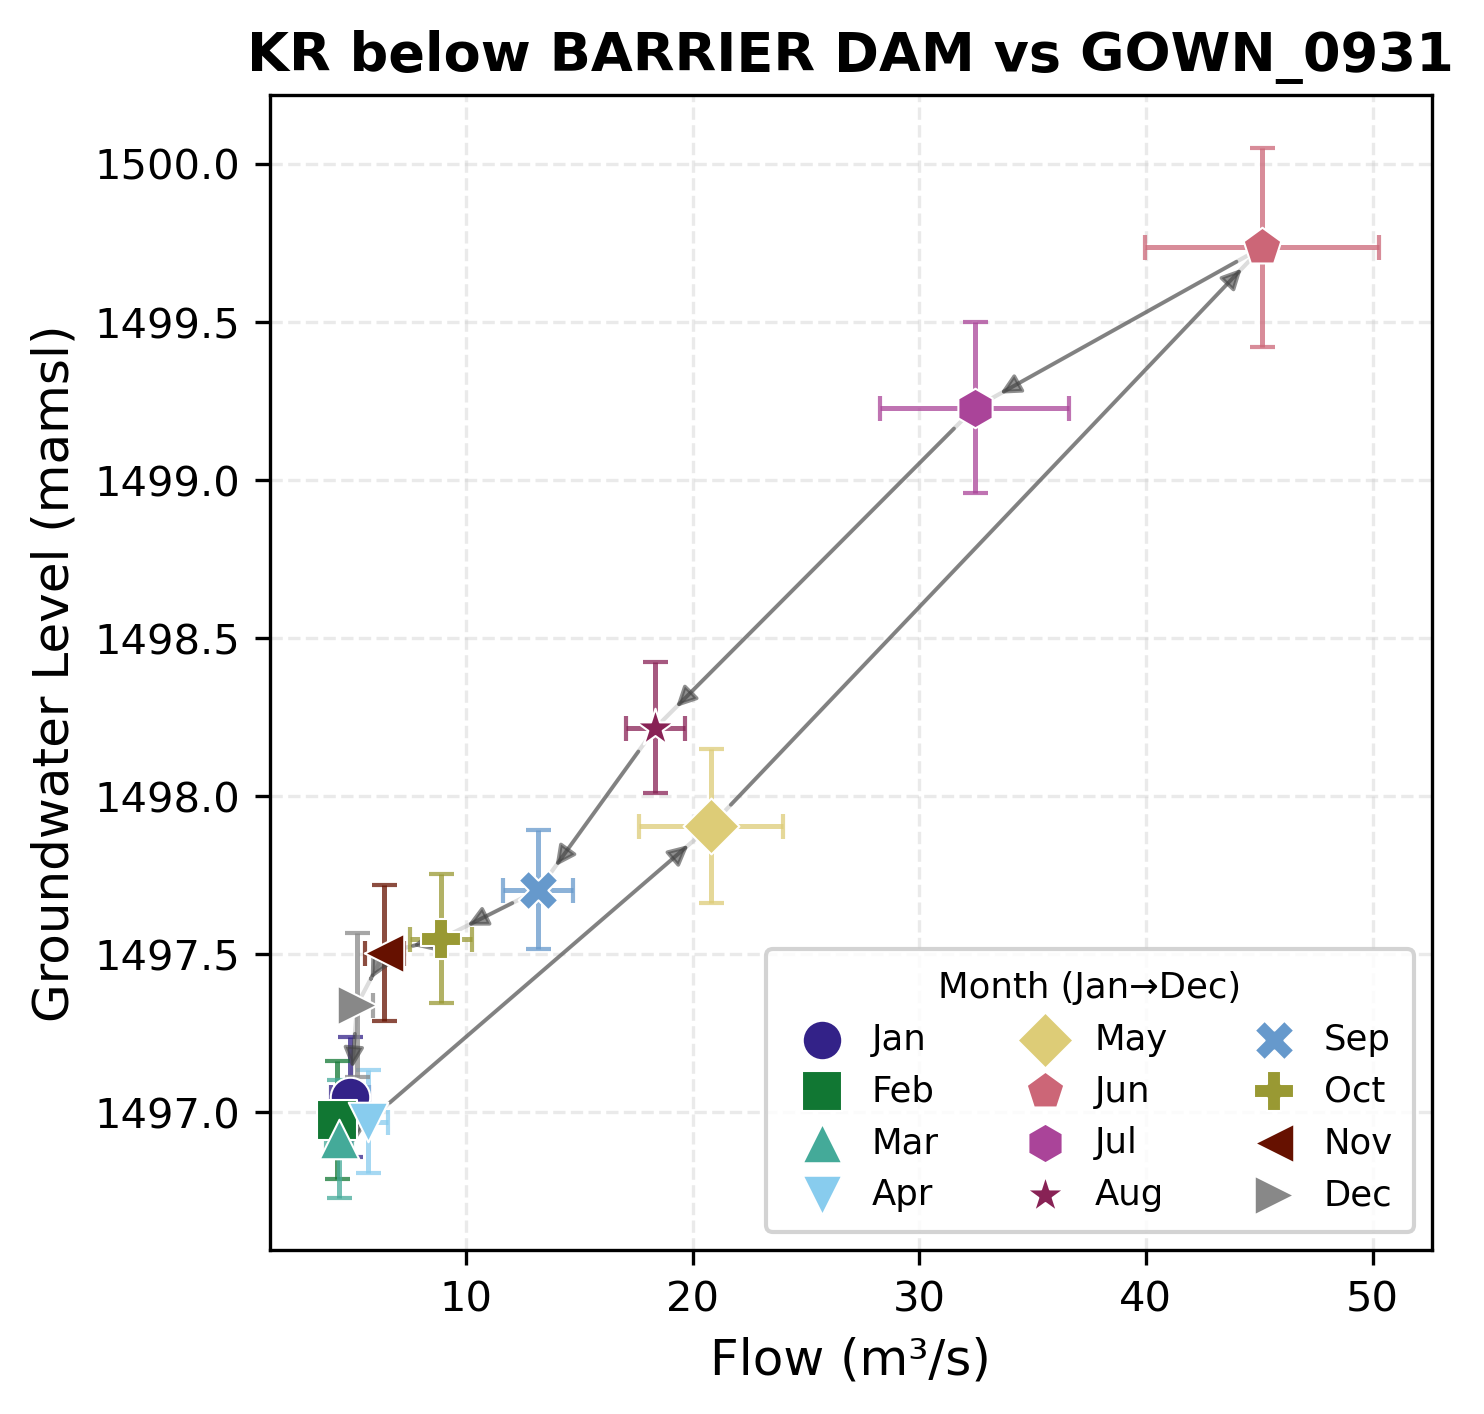

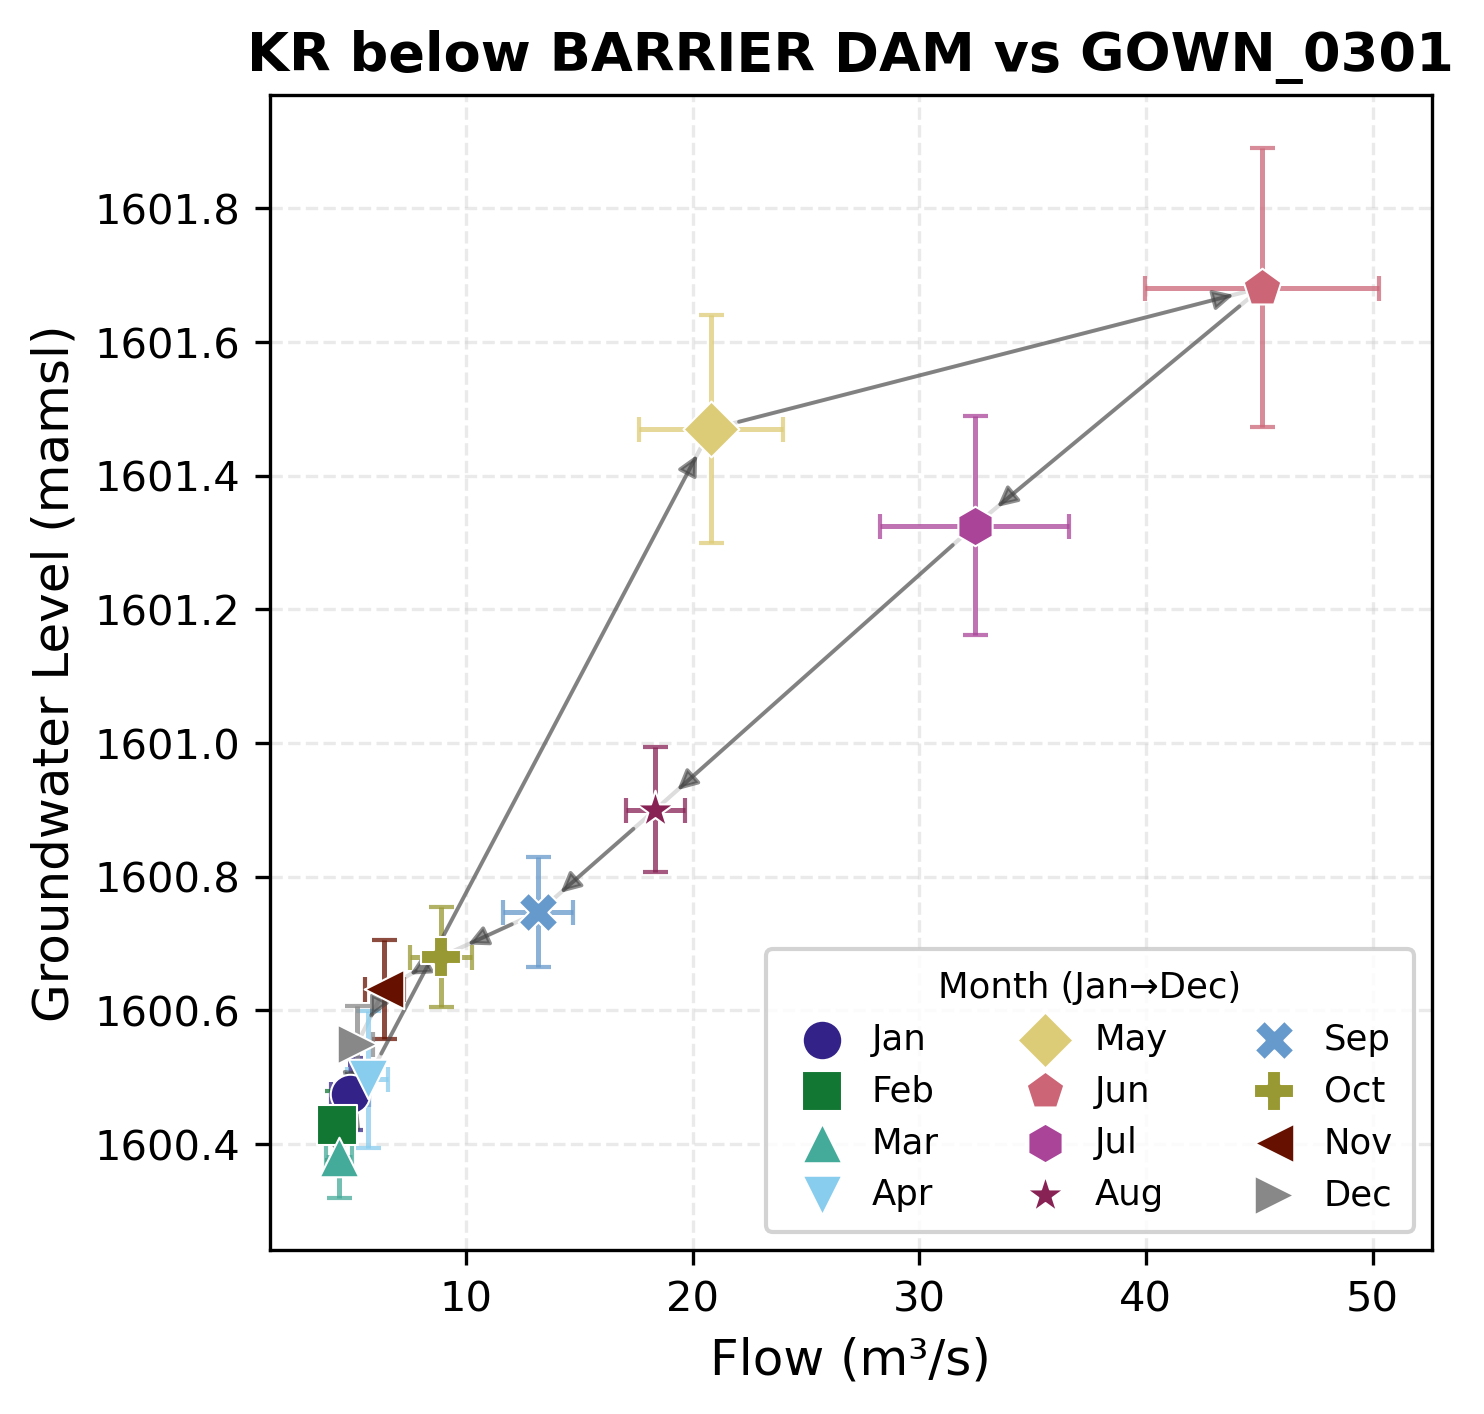

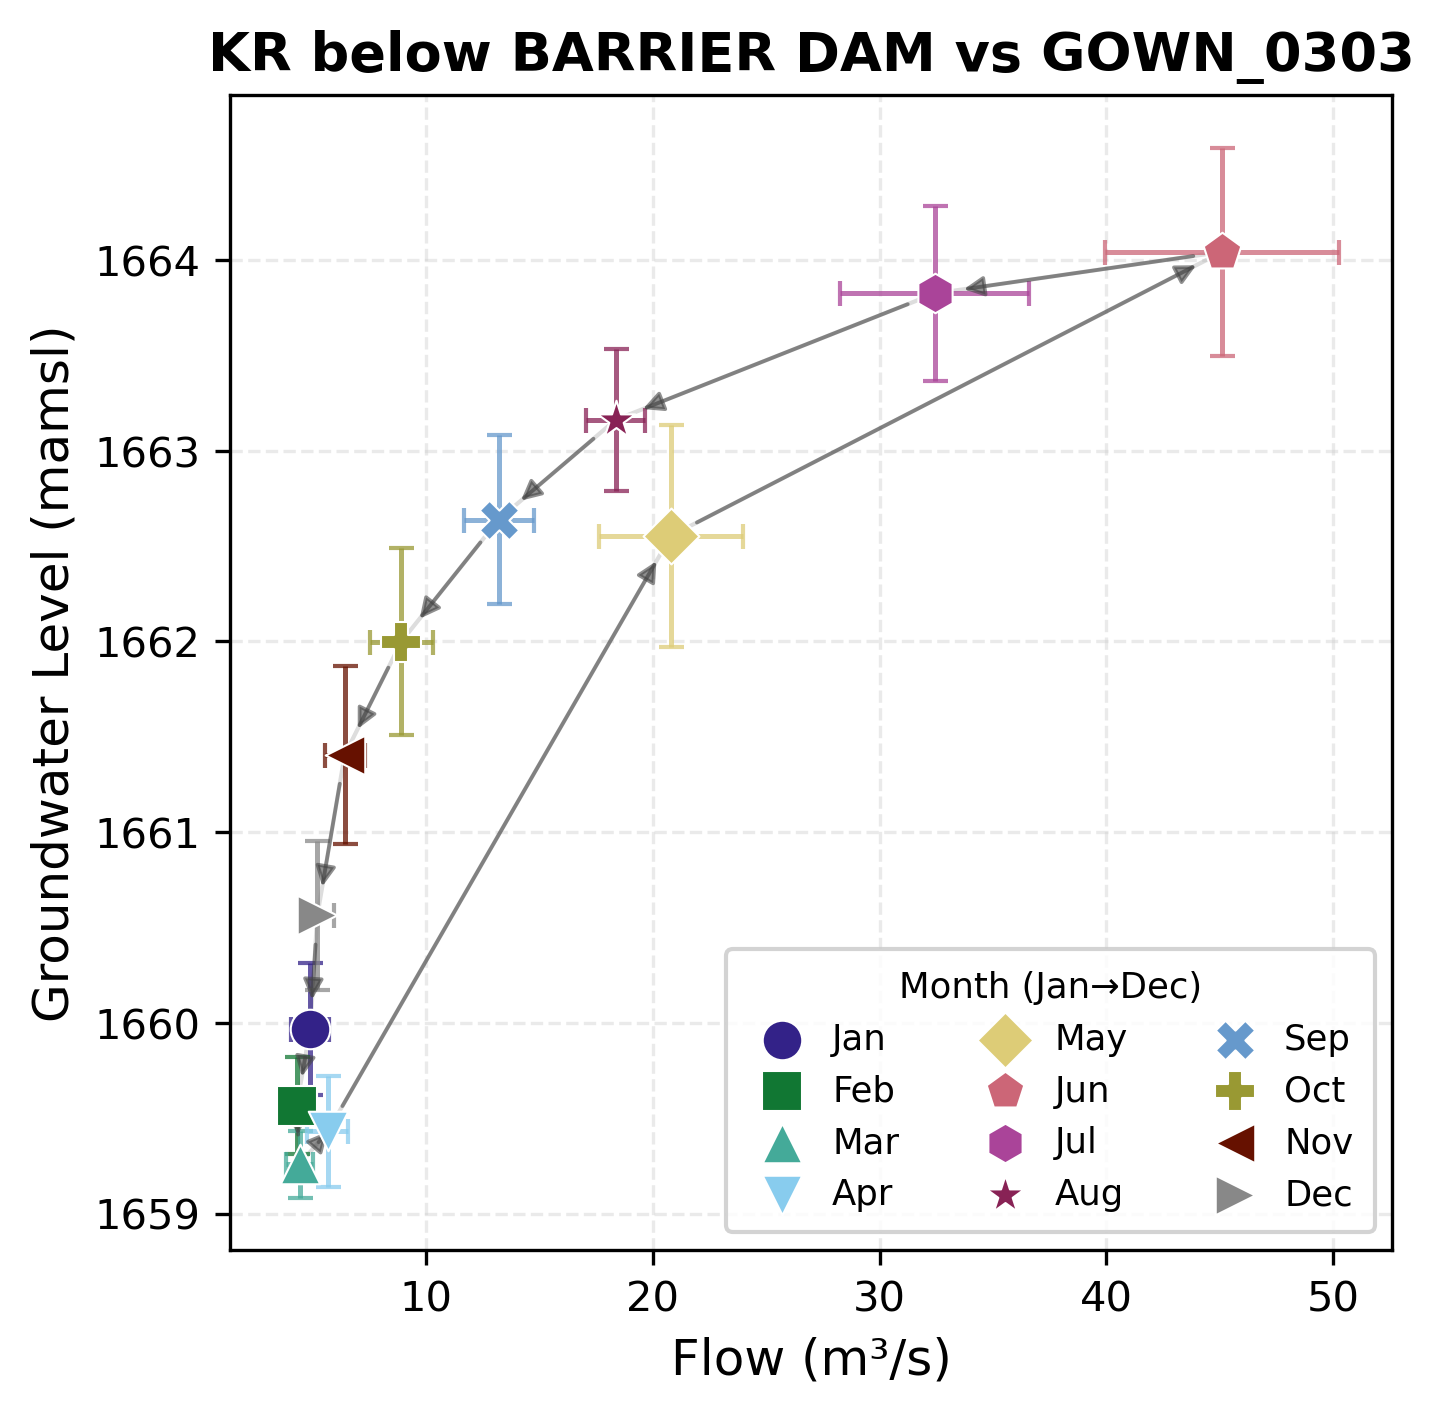

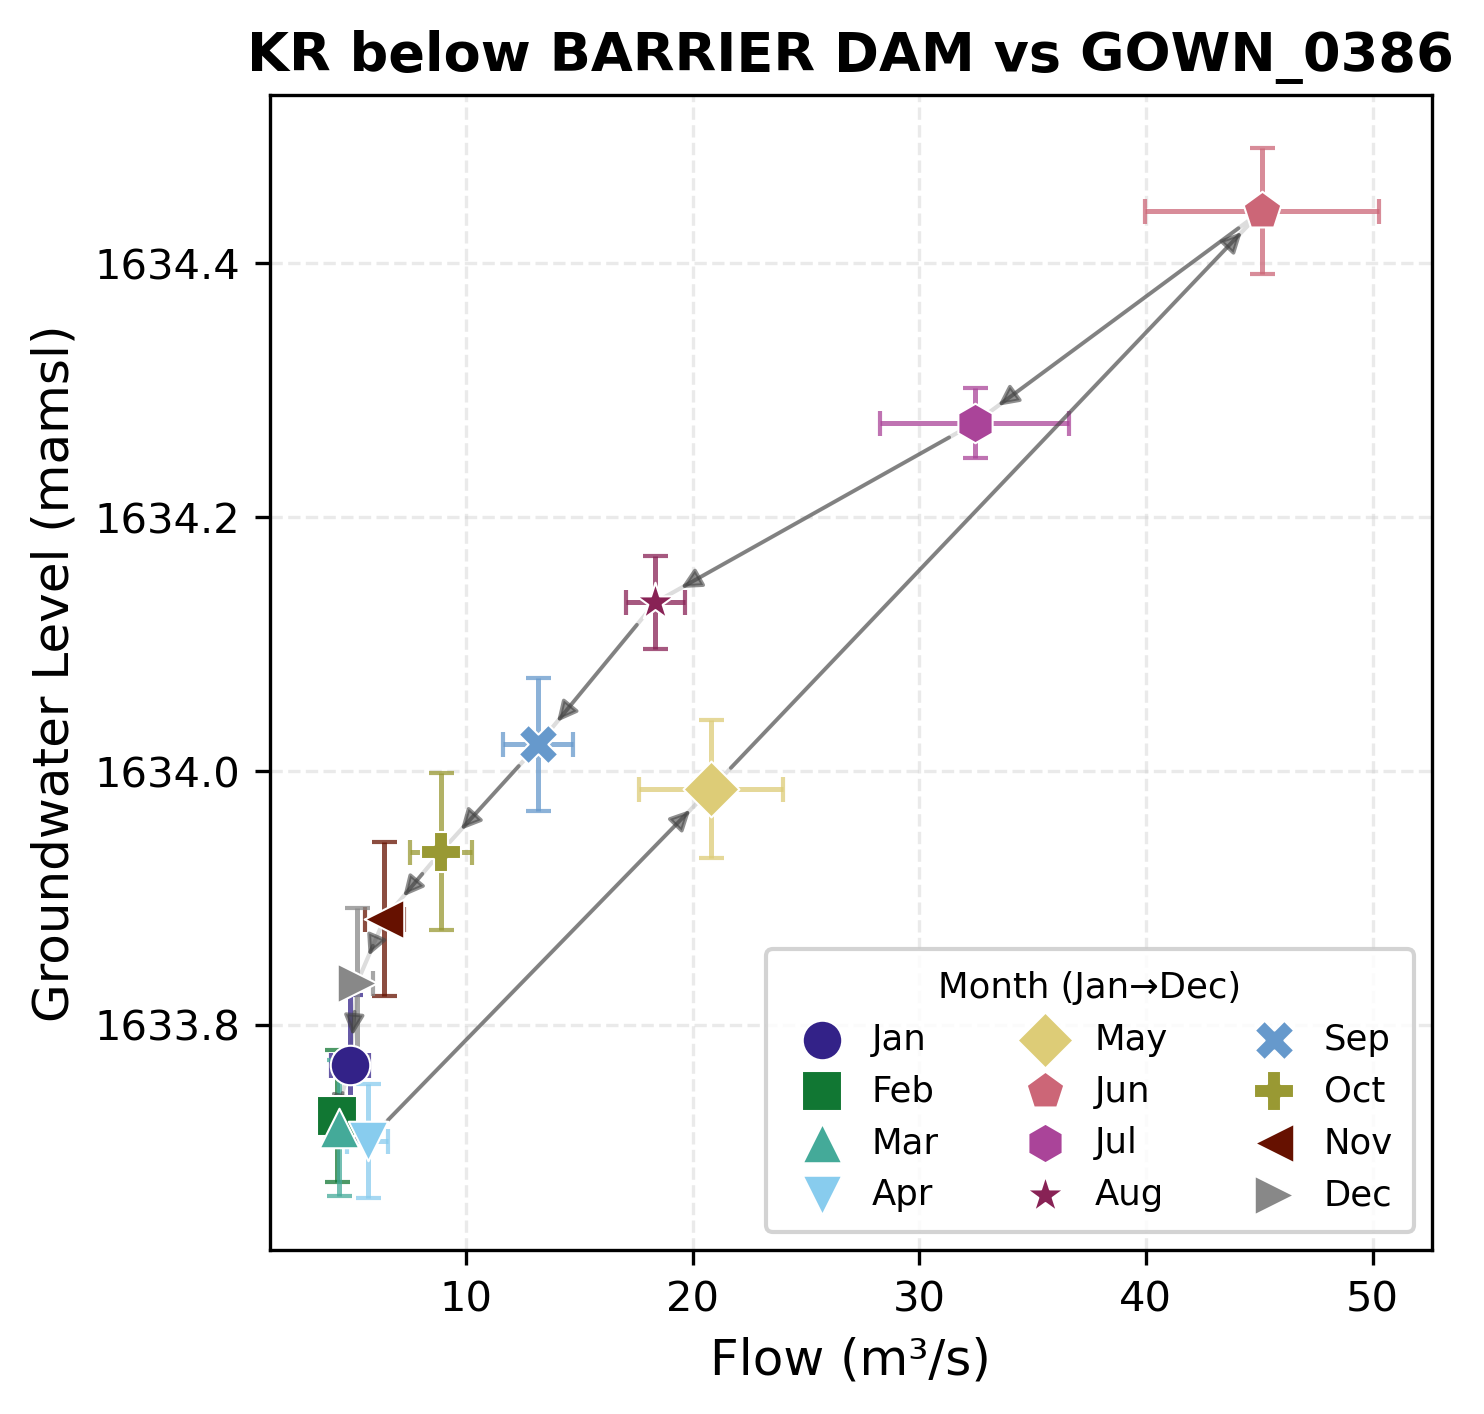

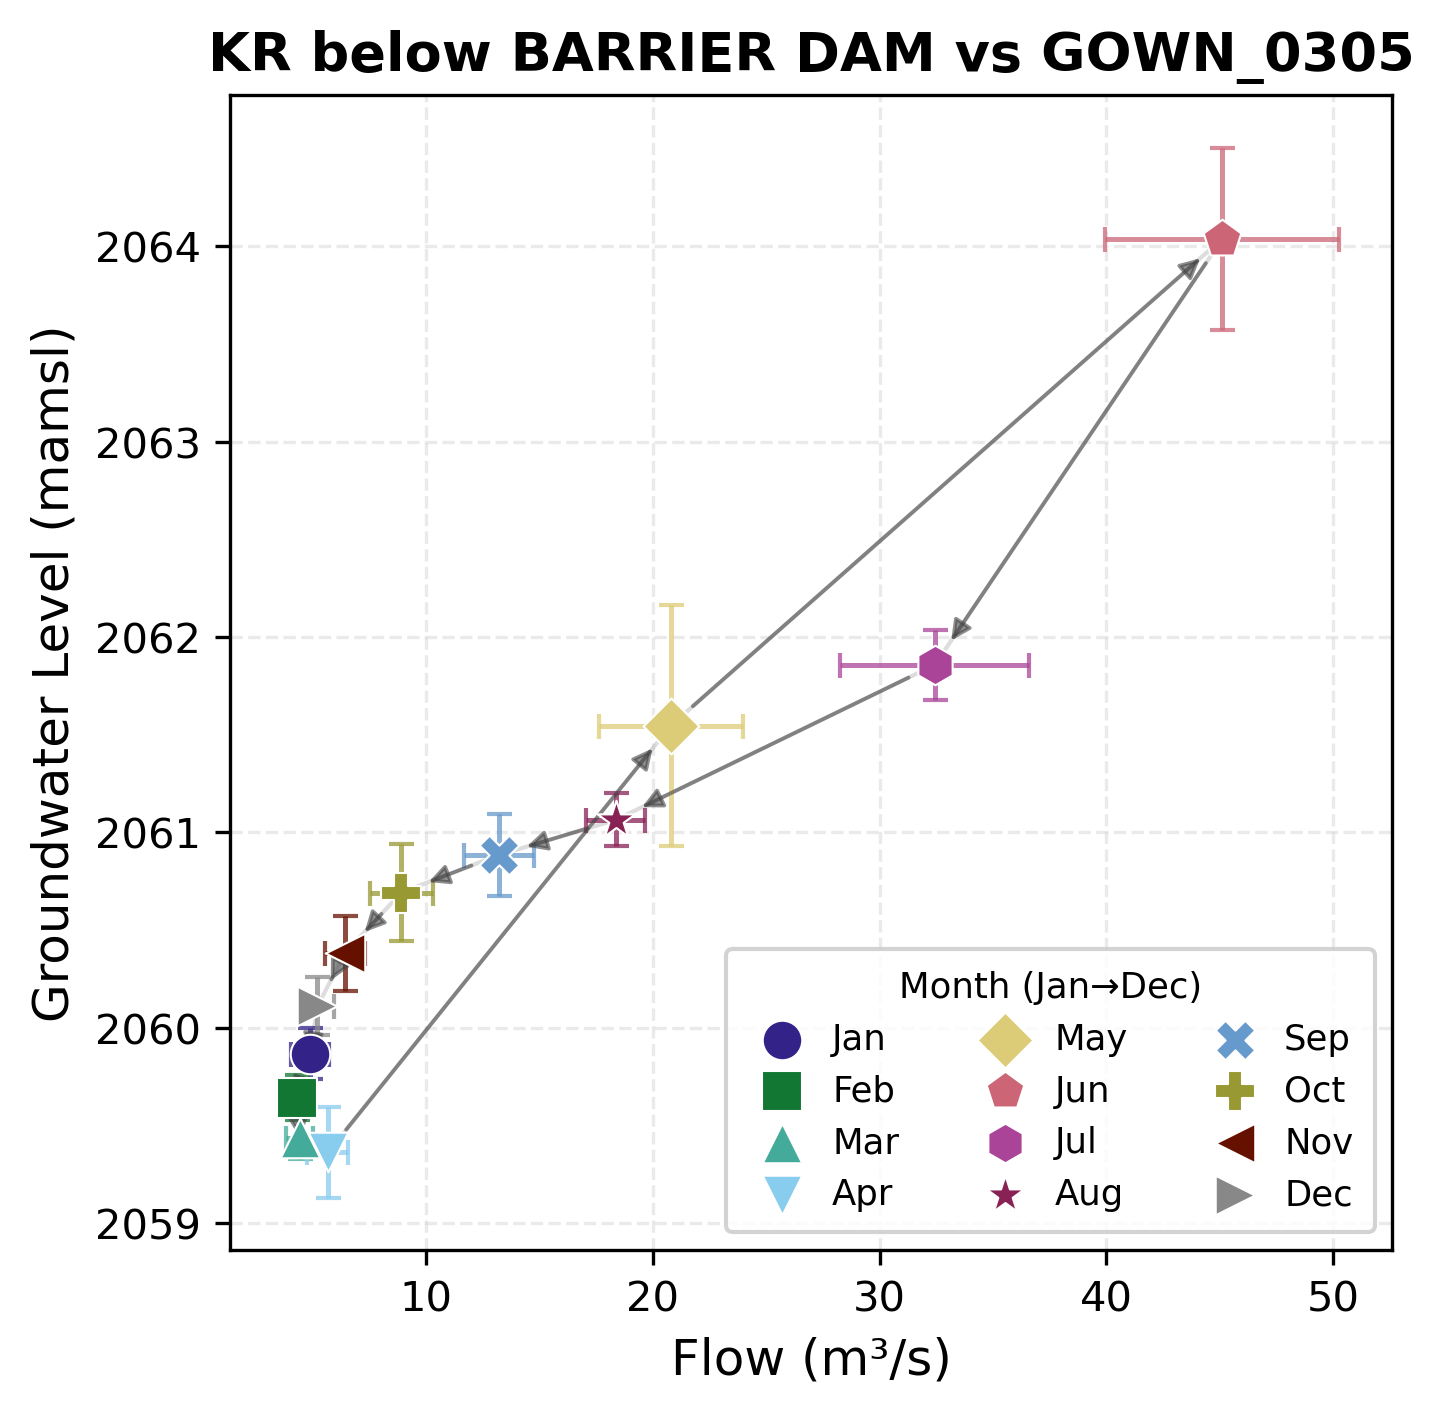

In [32]:
for well in marmot_creek_wells:
    plot_avg_monthly_hysteresis(GOWN[well], bl, f'KR below BARRIER DAM vs GOWN_{well}', start='2005', end='2024')

# Lower Kananaskis Lake vs MC Wells

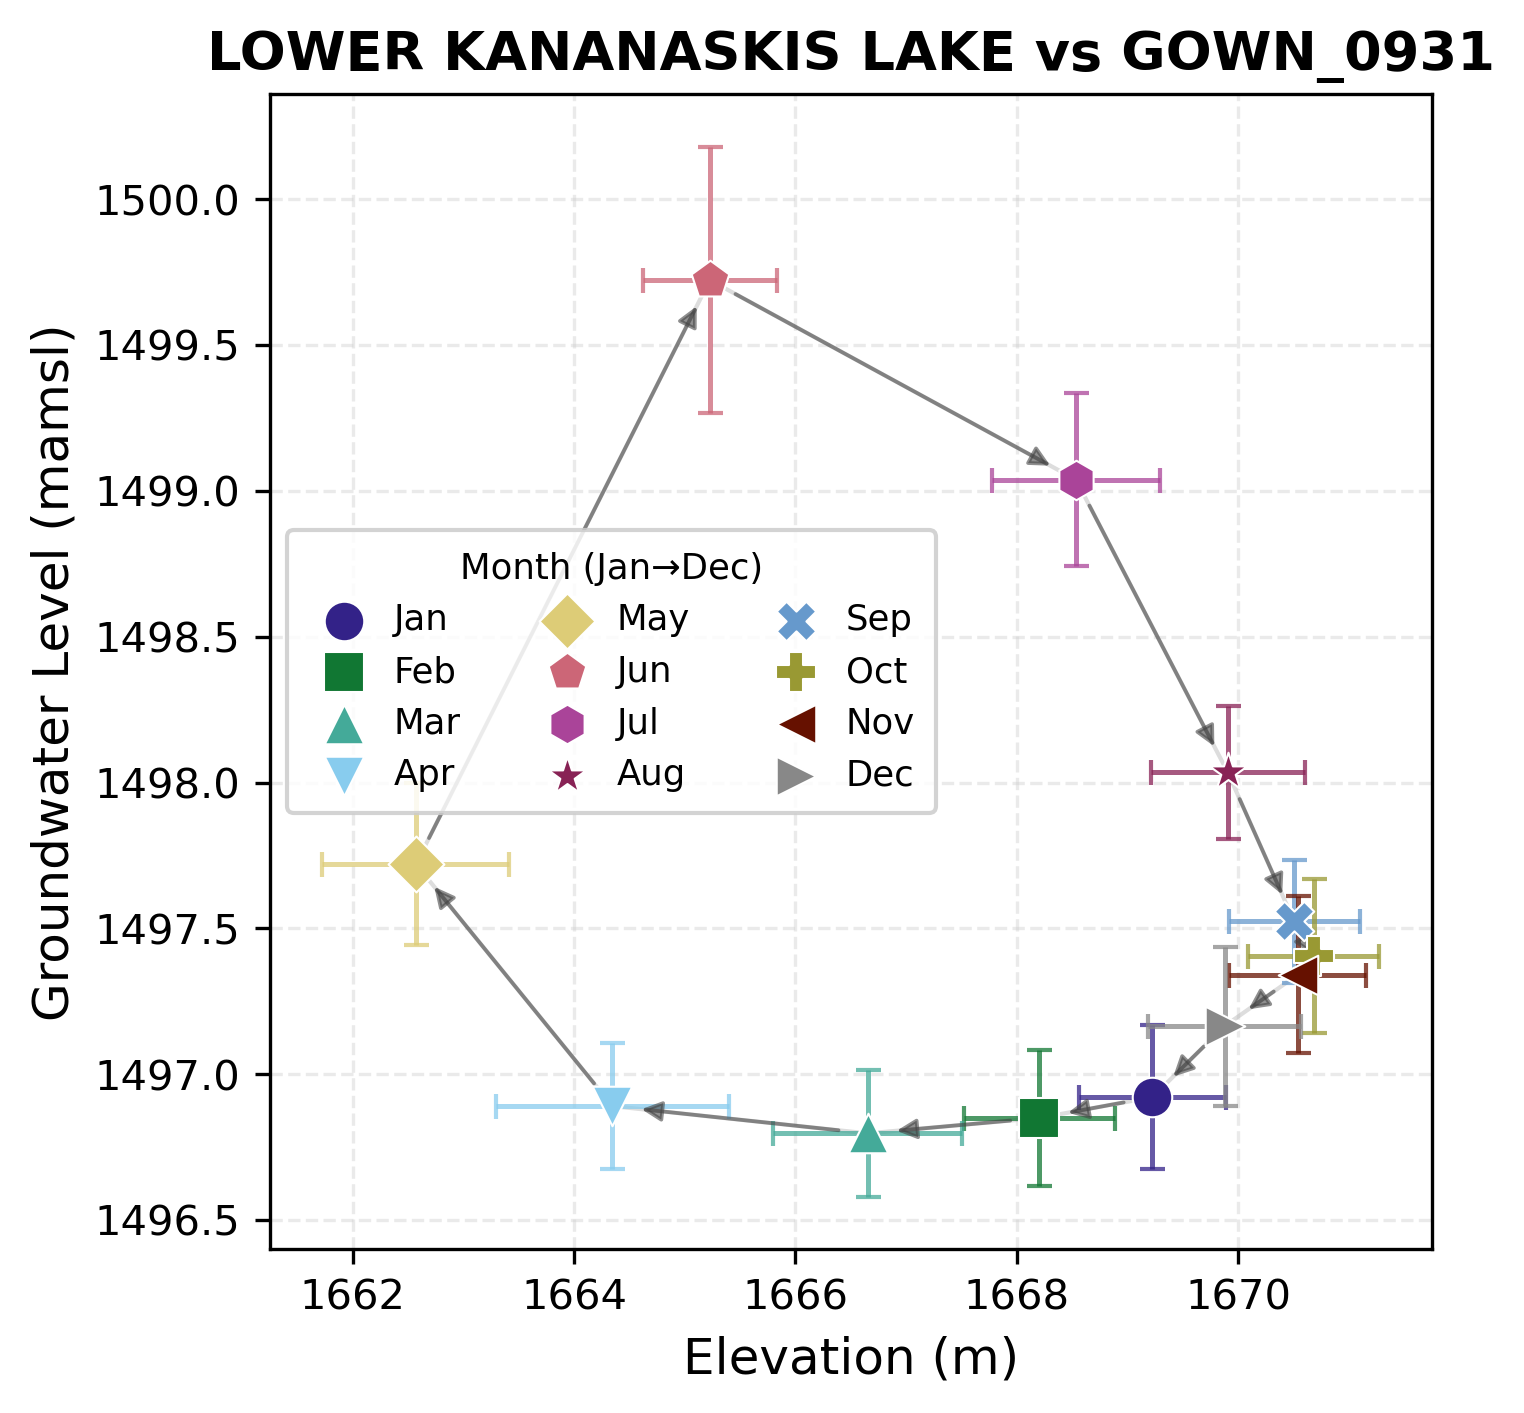

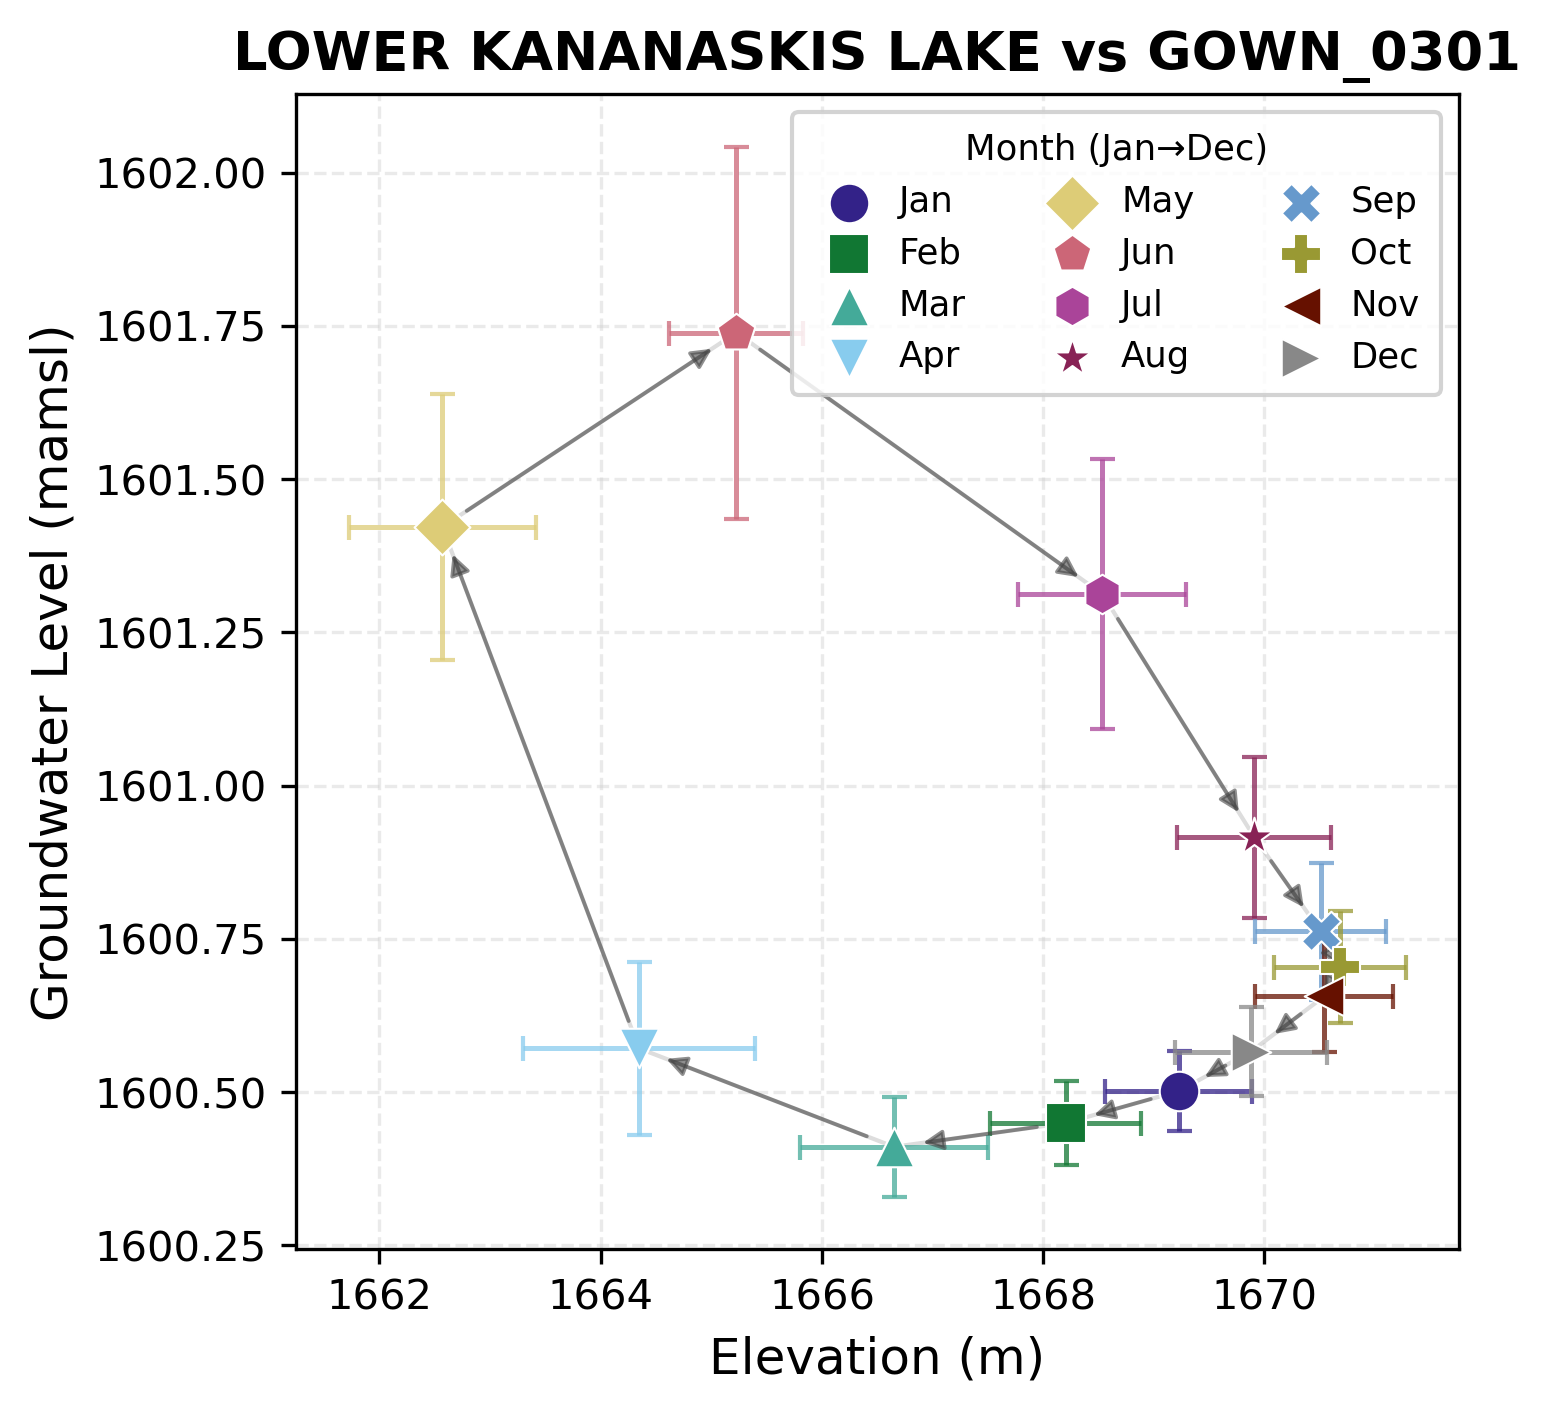

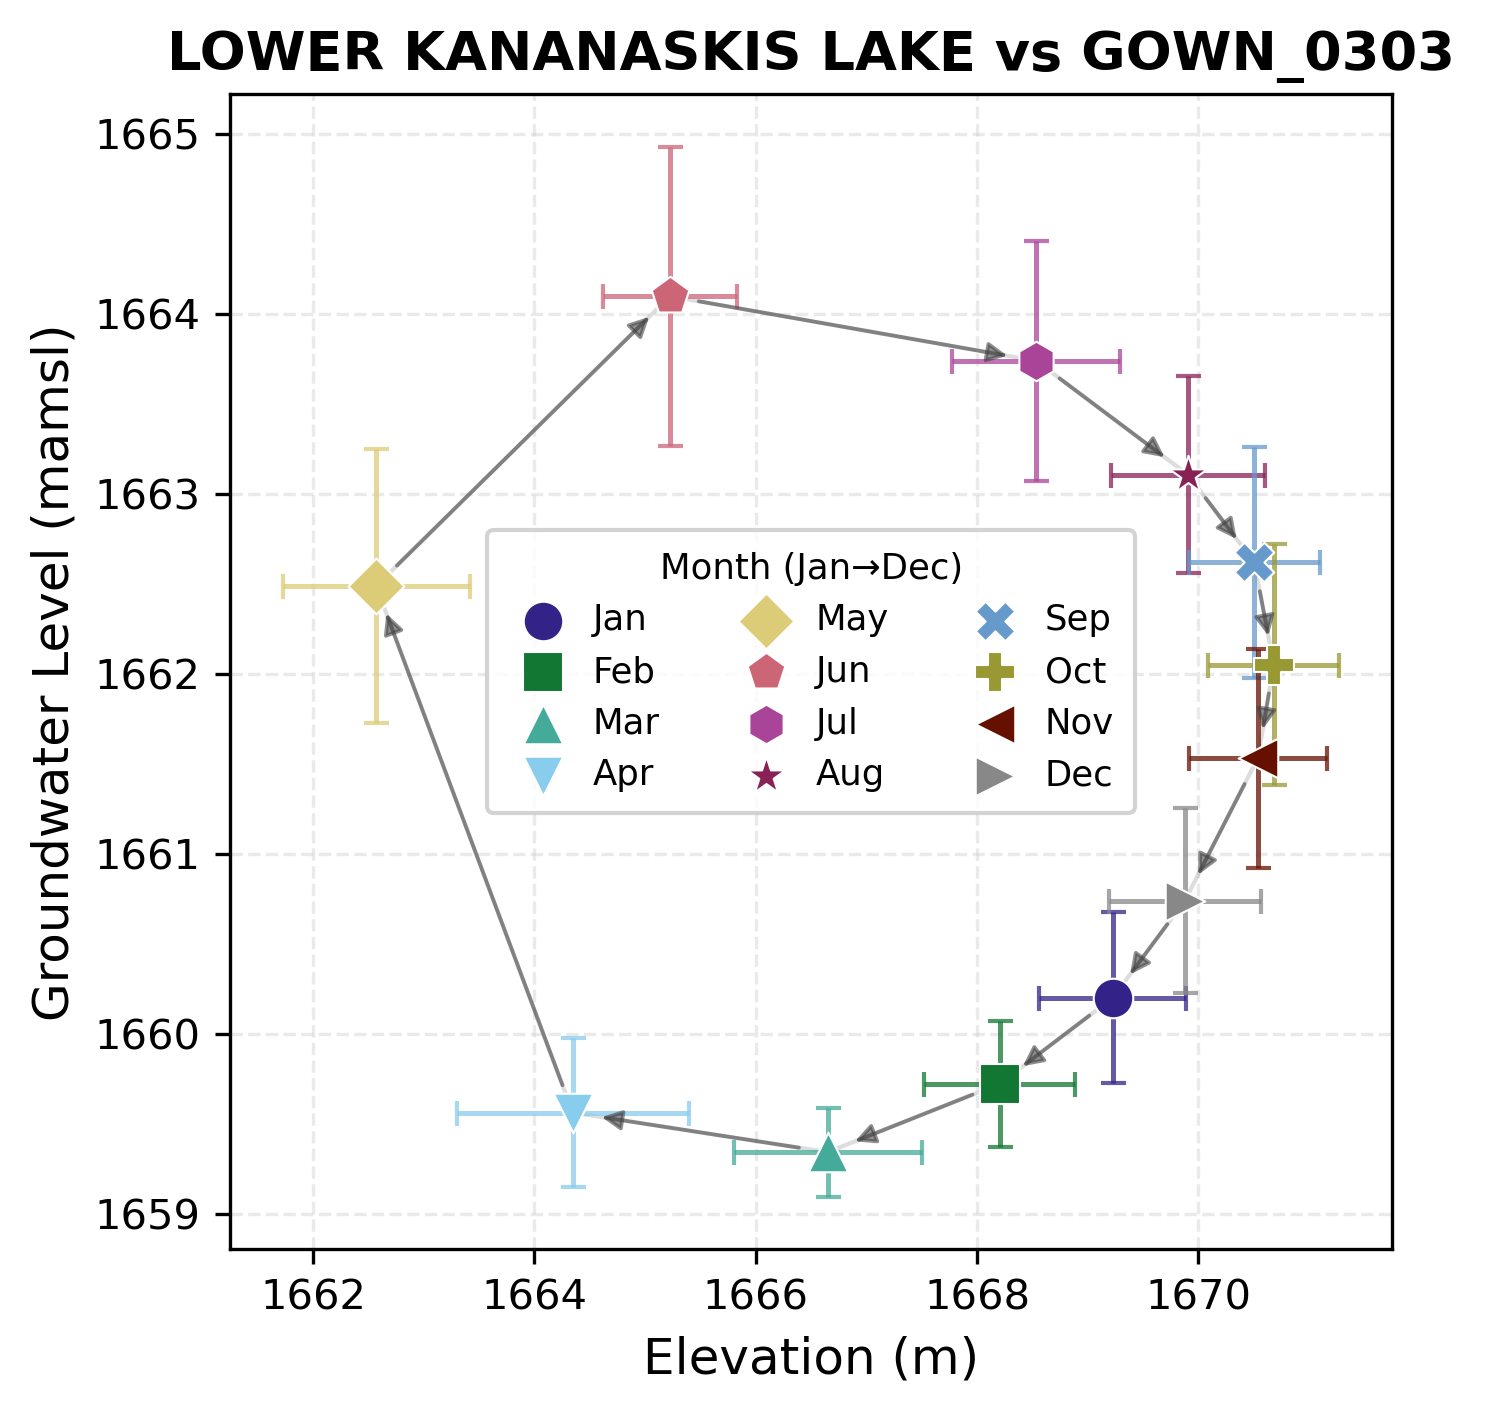

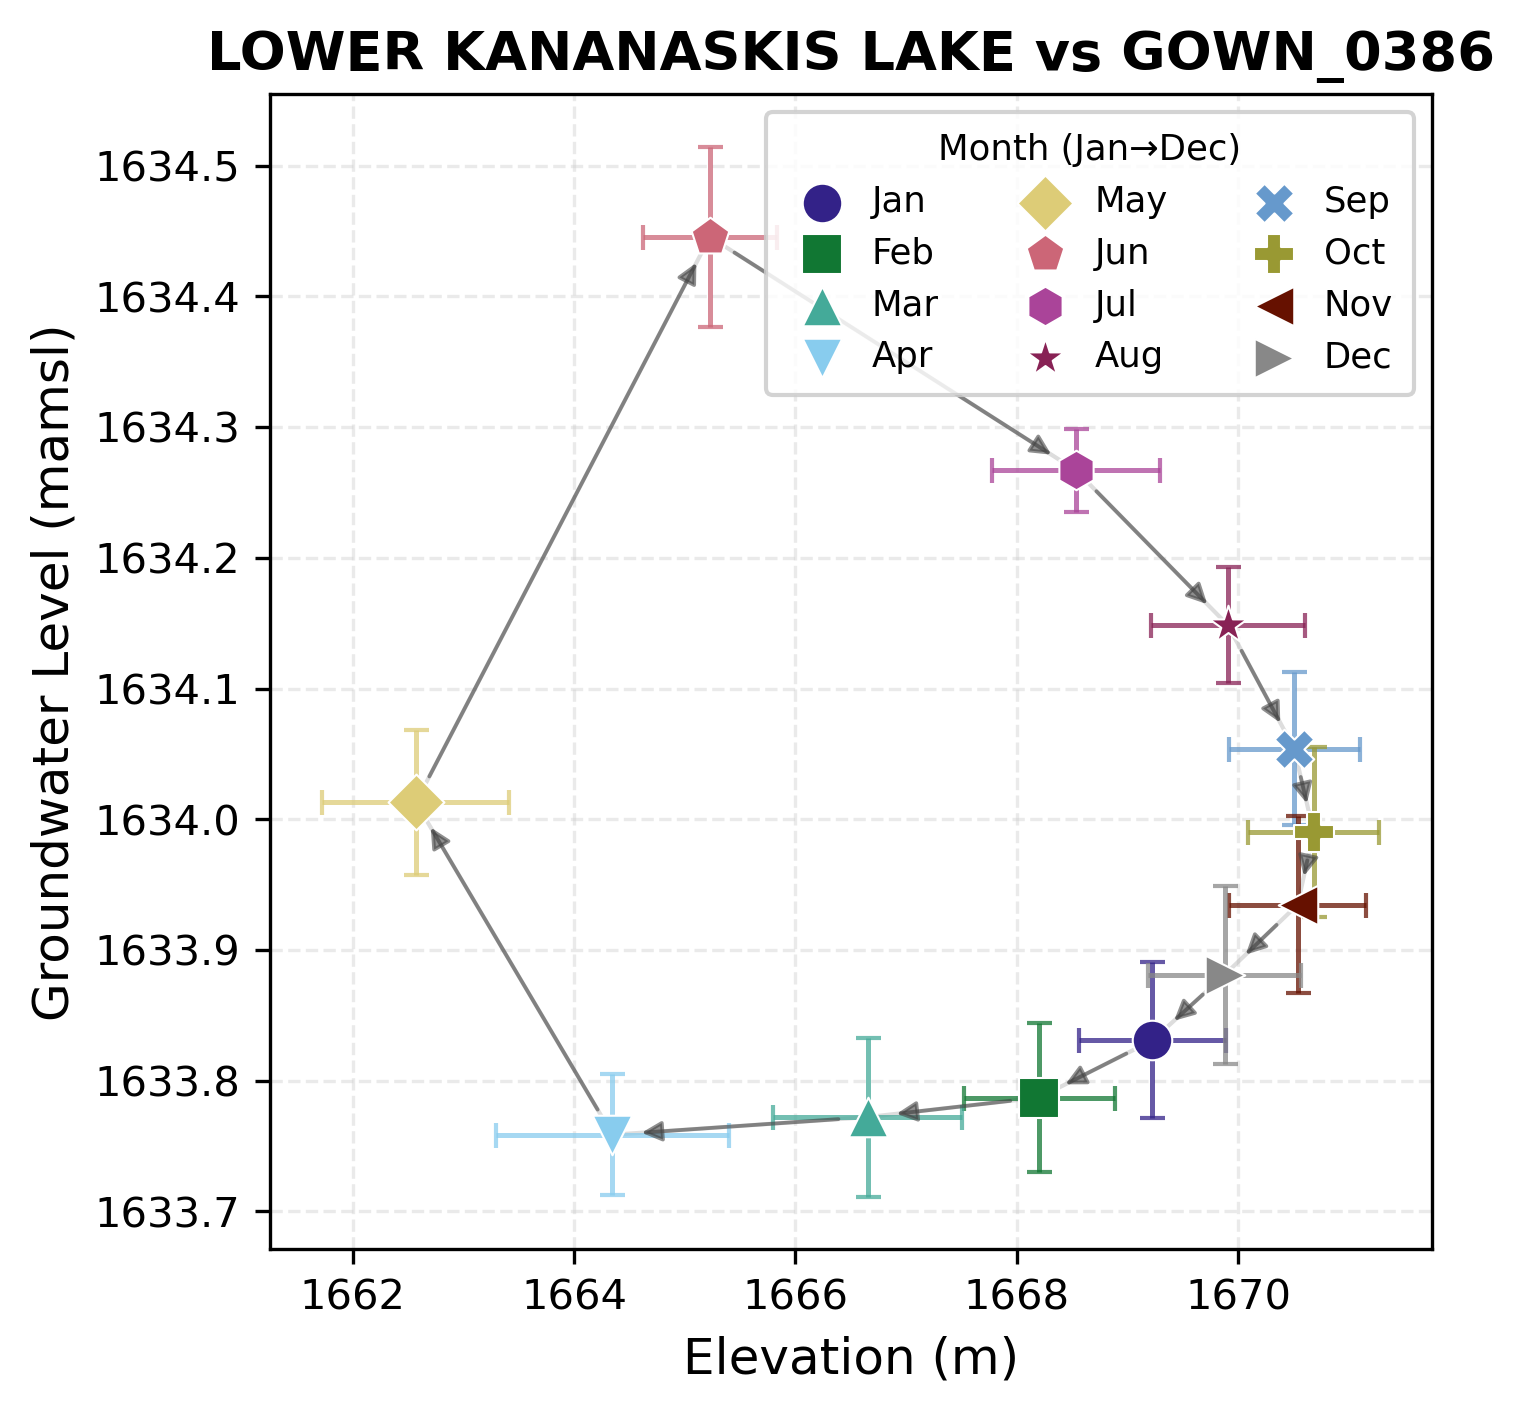

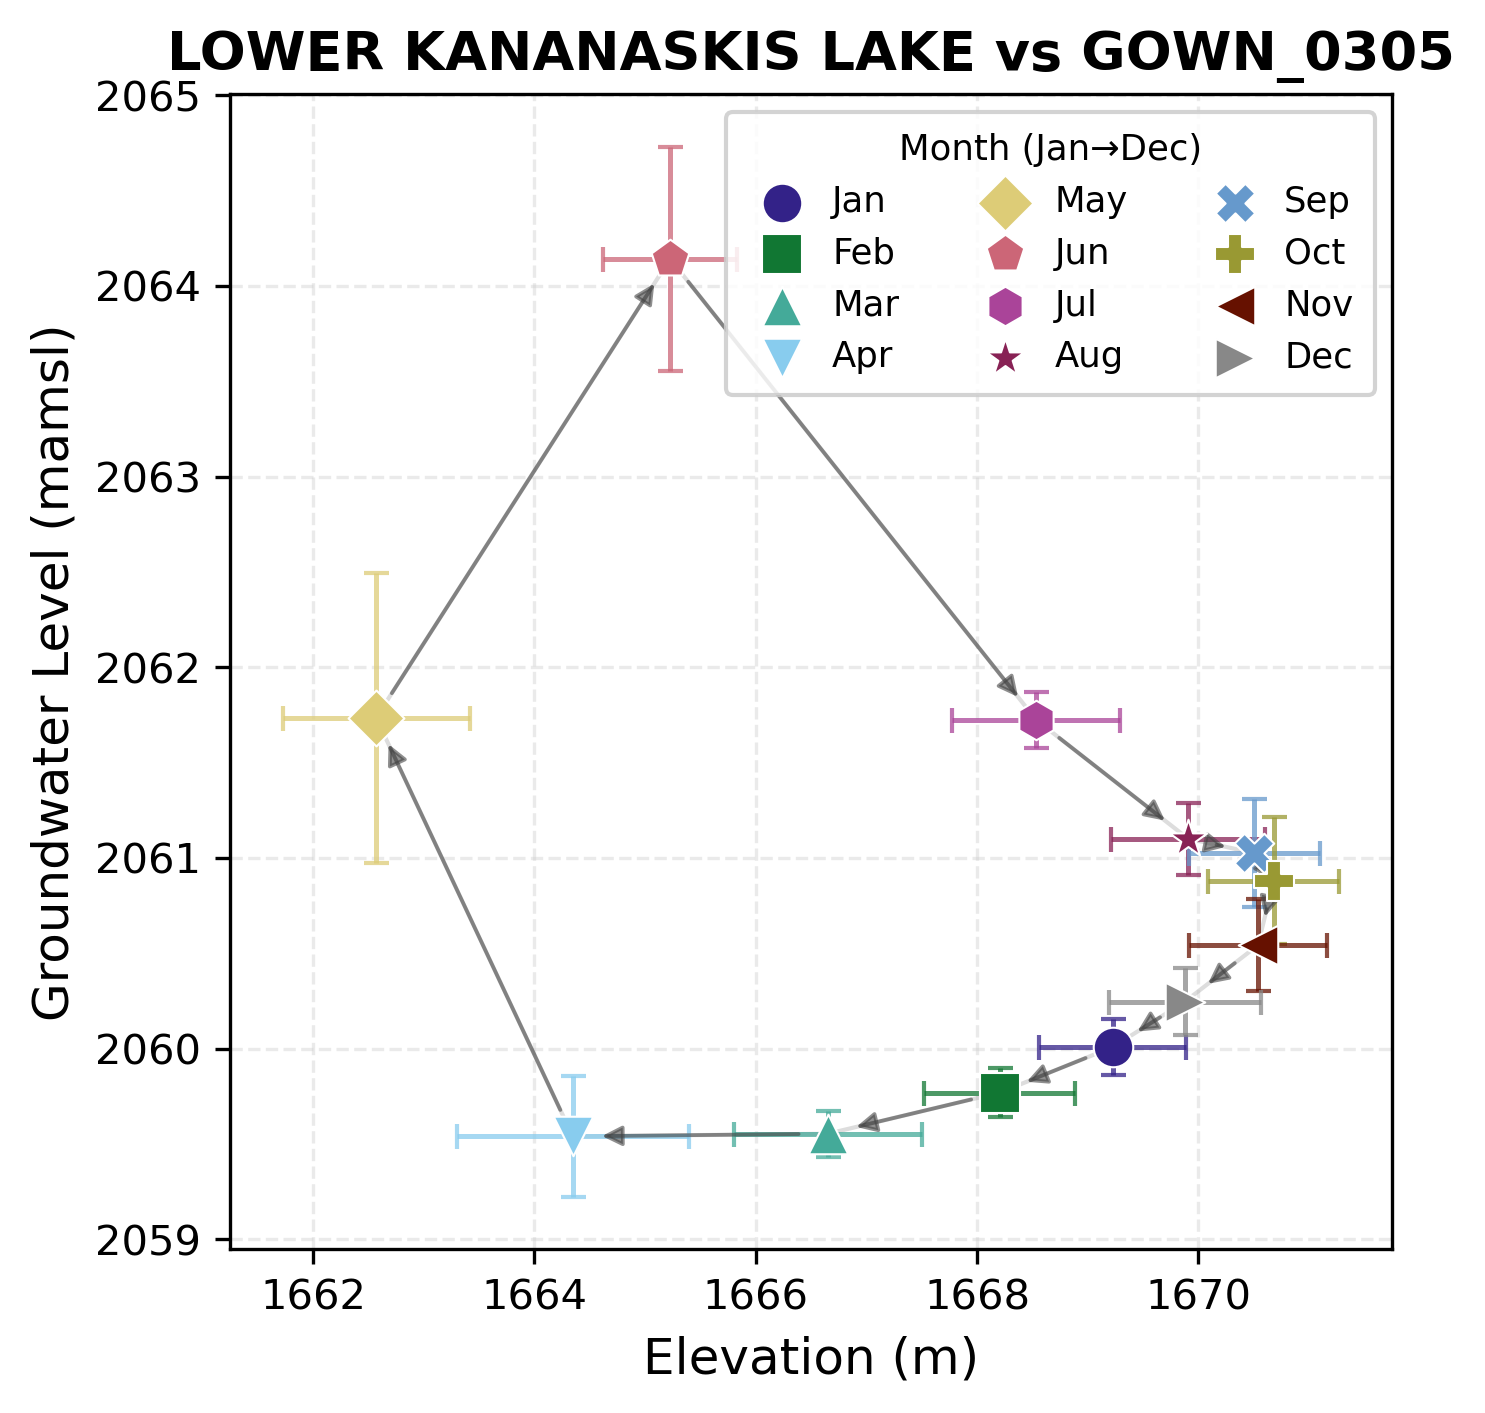

In [59]:
for well in marmot_creek_wells:
    plot_avg_monthly_hysteresis(GOWN[well], lkl, f'LOWER KANANASKIS LAKE vs GOWN_{well}', start='2005', end='2017', ylab='Elevation (m)')

# Jumpingpound Creek vs MC Wells

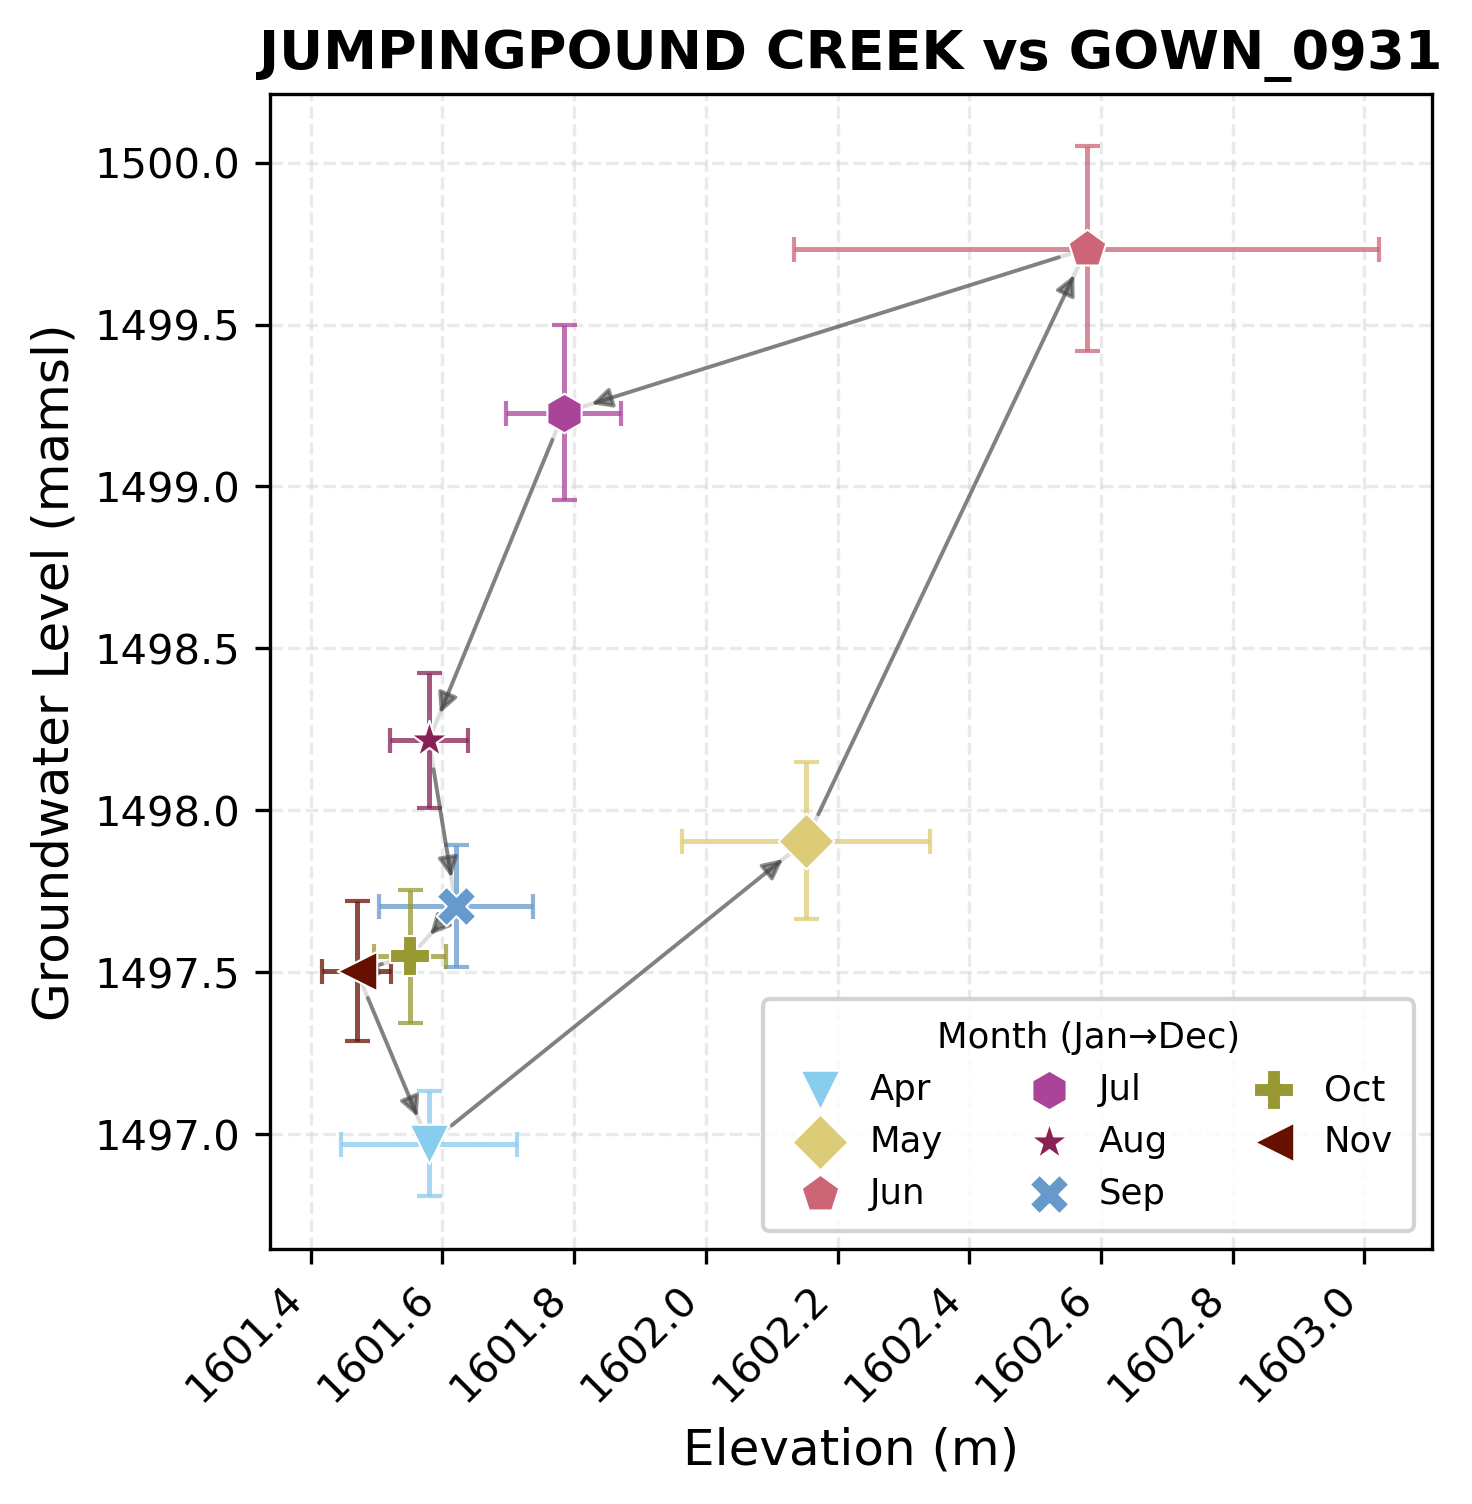

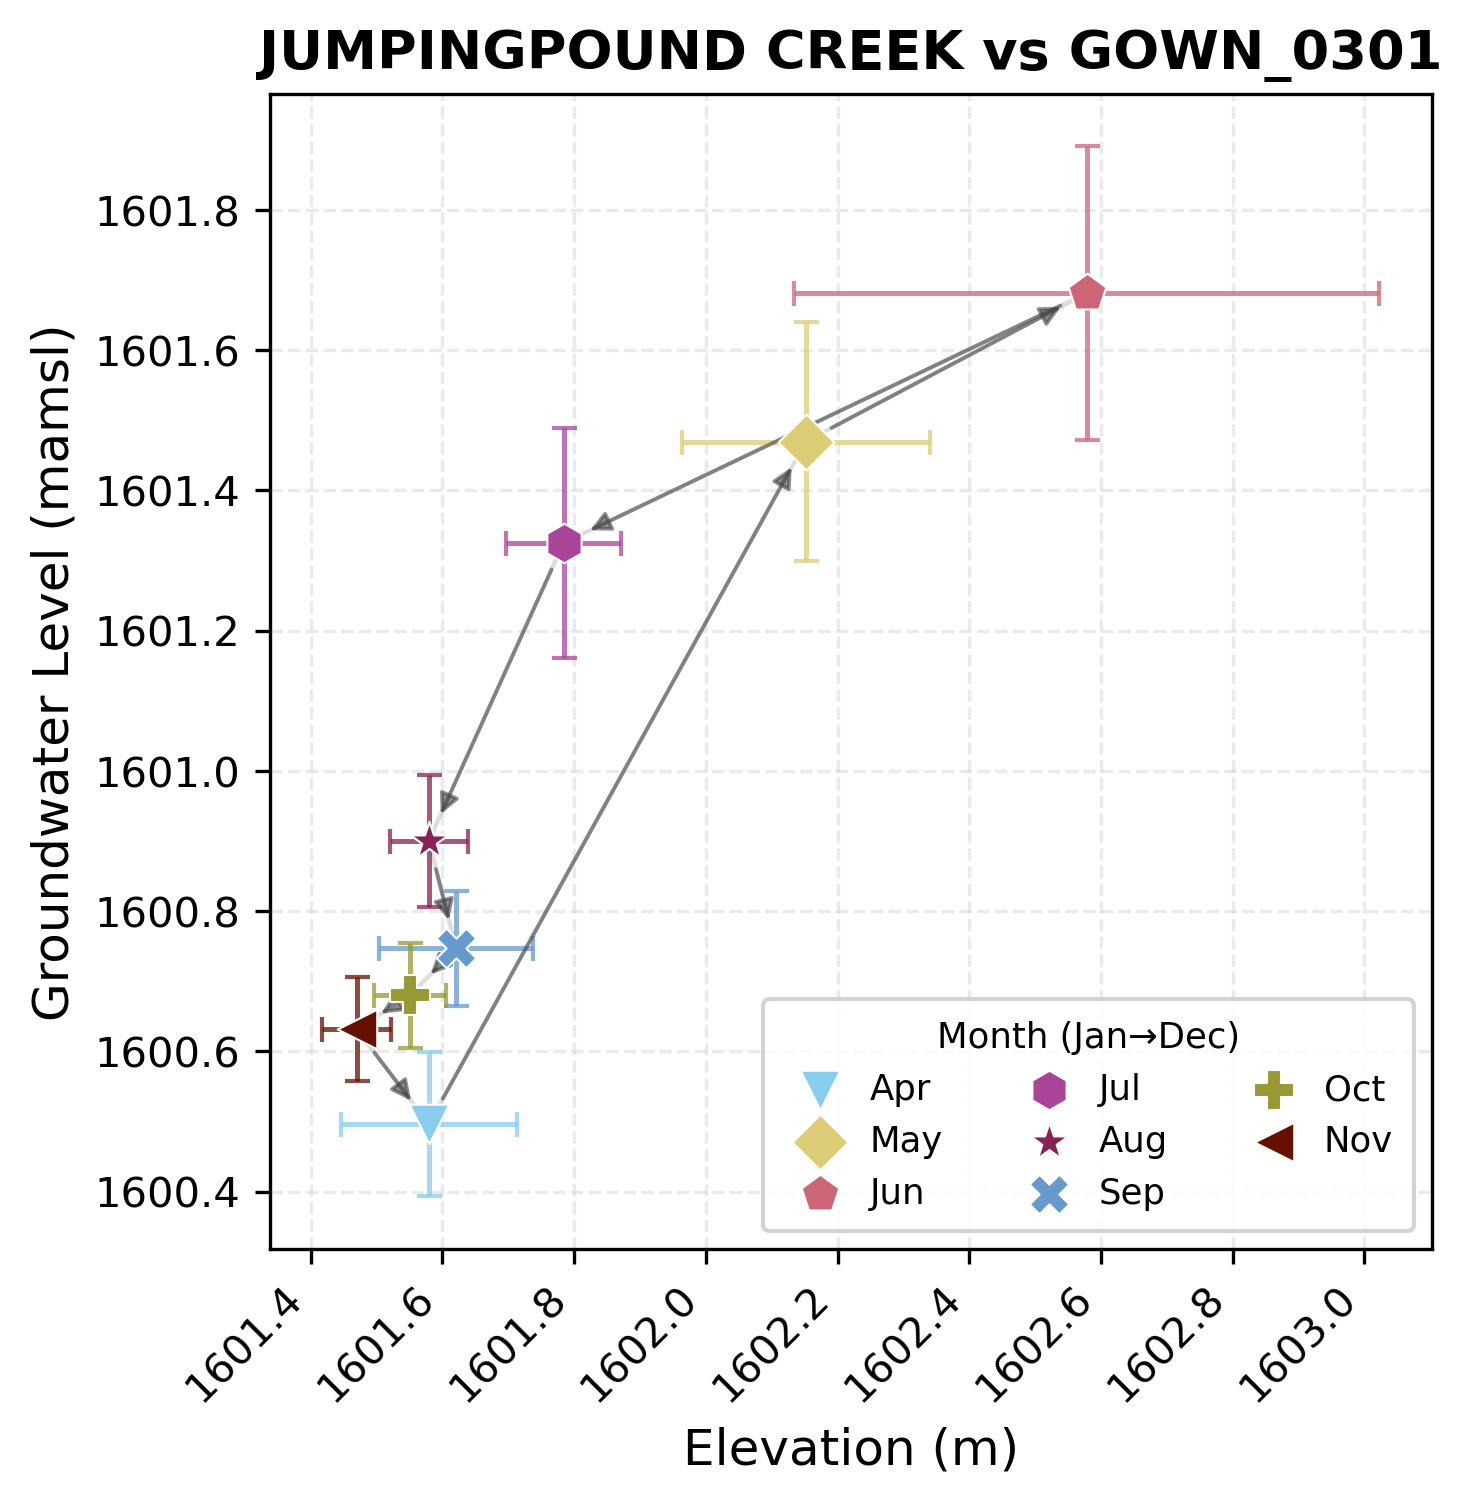

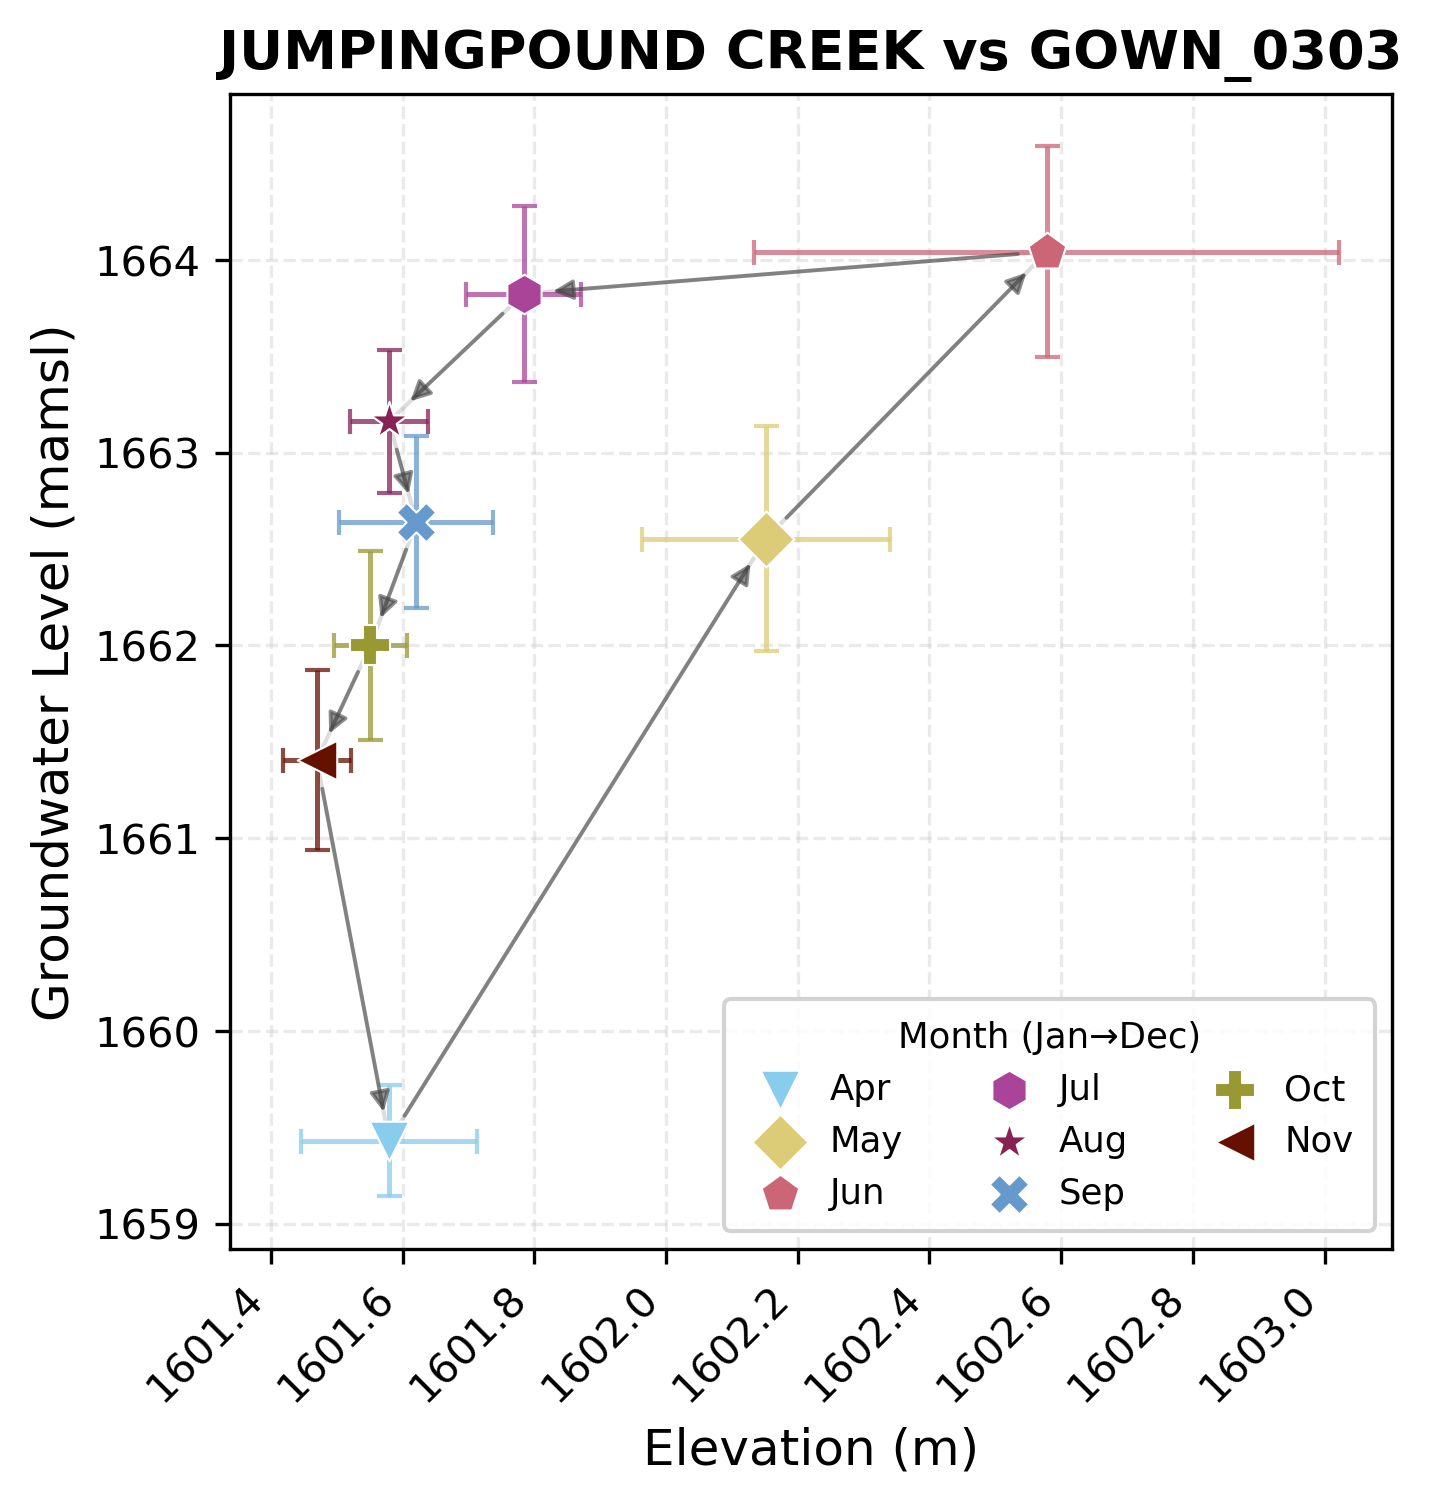

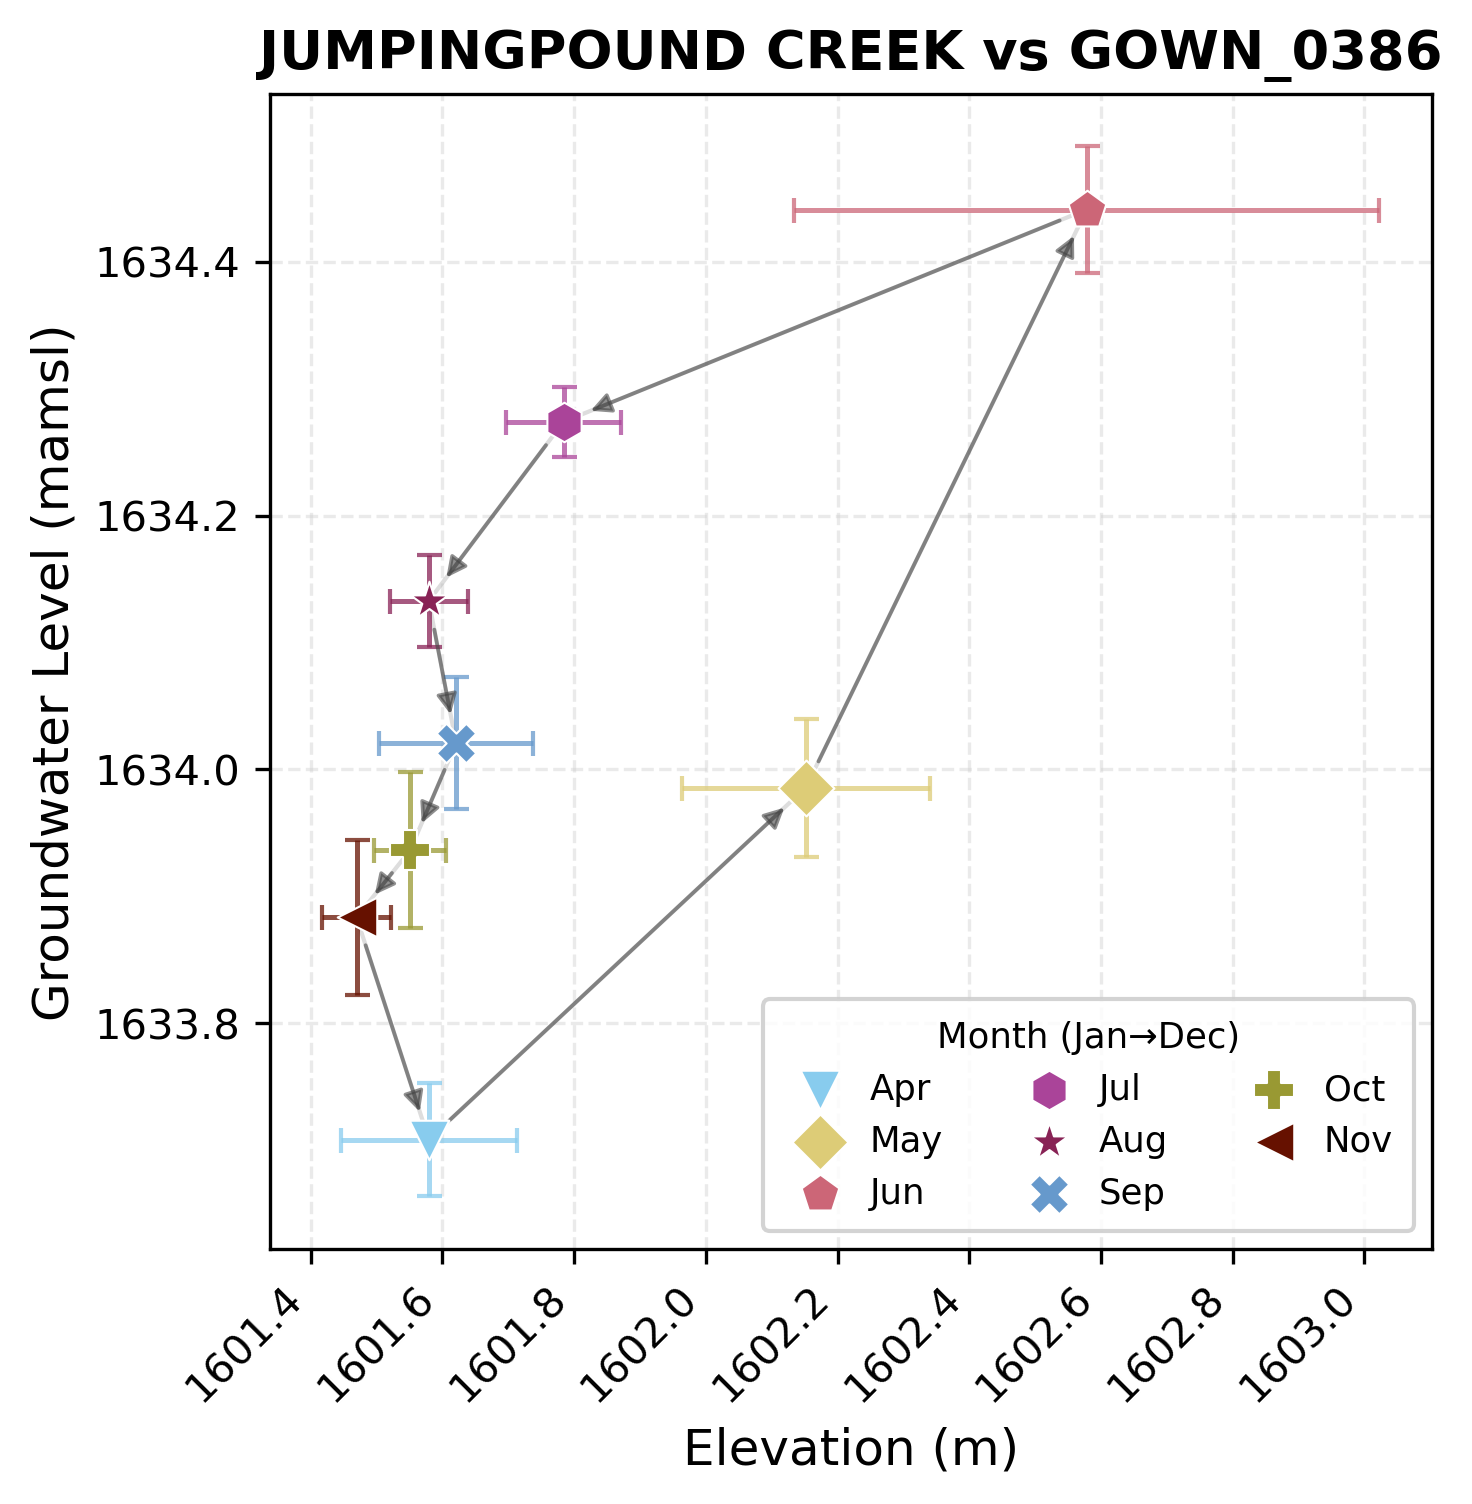

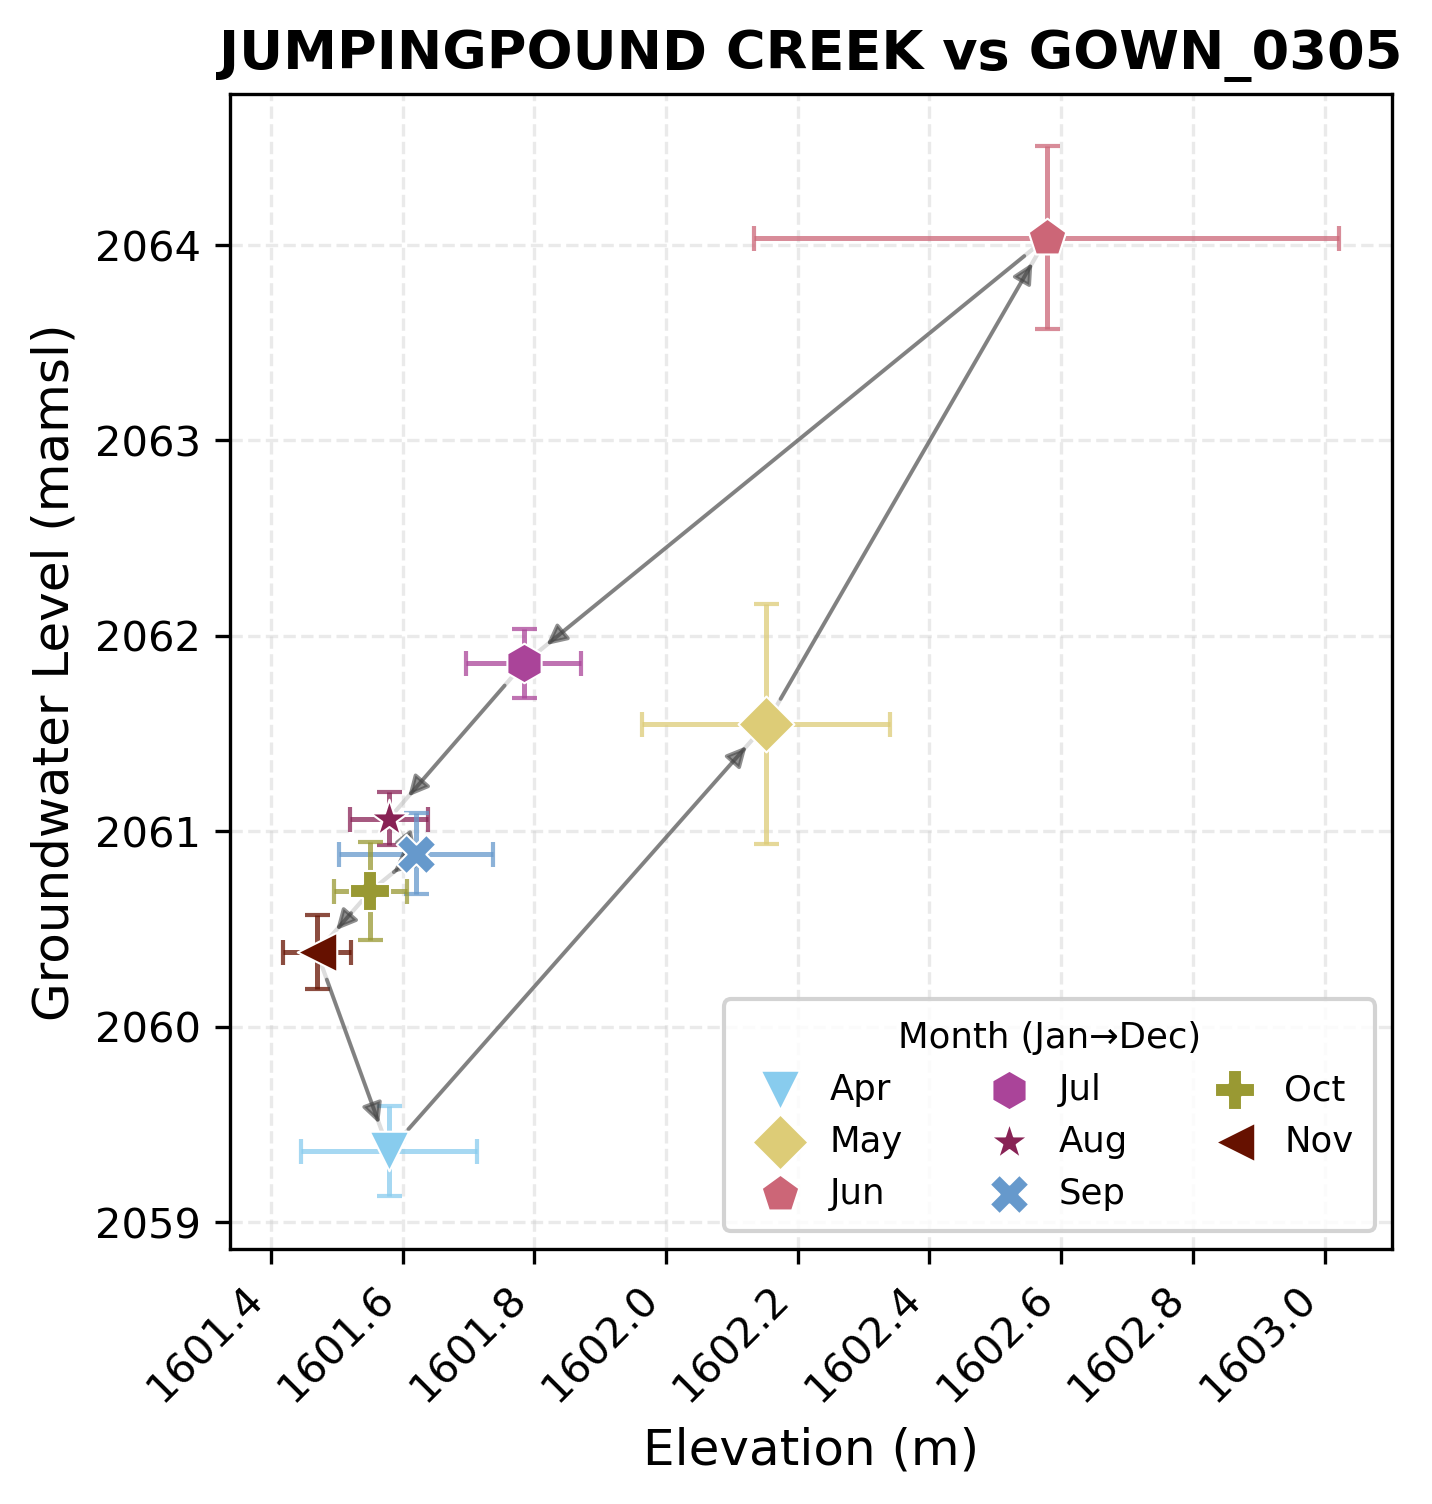

In [76]:
for well in marmot_creek_wells:
    plot_avg_monthly_hysteresis(GOWN[well], jcnc, f'JUMPINGPOUND CREEK vs GOWN_{well}', start='2005', end='2024', ylab='Elevation (m)')